# Predicción de cancelaciones hoteleras
## 0. Portada y guía de lectura

**Objetivo:** estimar, al reservar, qué reservas tienen mayor riesgo de cancelarse para orientar una revisión por Revenue Management. La configuración final es XGBoost con umbral **0,25**, elegido antes de evaluar test mediante validación temporal en entrenamiento.

**Resultado final:** en las **23.831** reservas elegibles de test (enero–agosto de 2017), AUC-ROC **0,764**, F1 **0,586**, Precision **0,450** y Recall **0,840**. Se detectaron **6.224** de **7.409** cancelaciones, con **7.611** alertas sobre reservas no canceladas. El **58,1 %** quedó señalado; son cifras descriptivas, no una estimación de ahorro.

**Índice:** 1. Negocio · 2. Entorno · 3. Datos y calidad · 4. Variables y partición temporal · 5. EDA de negocio · 6. Ingeniería de variables · 7. Preprocesamiento · 8. Regresión logística · 9. Modelos alternativos · 10. Selección · 11. Test · 12. SHAP · 13. Uso y limitaciones · 14. Referencias y conclusiones.

## 1. Problema de negocio
Cada fila representa **una reserva**, y `is_canceled` indica si se cancela (1) o no (0).
Revenue Management usaría el riesgo **al reservar** para valorar incentivos, depósitos selectivos
o ajustes de overbooking, como propone el enunciado.

- **Falso positivo:** alertar sobre una reserva que no se cancela; puede provocar un incentivo innecesario o molestias.
- **Falso negativo:** no detectar una cancelación; deja menos tiempo para revender la habitación.

El umbral se fija mediante validación cruzada temporal dentro de entrenamiento, antes de evaluar test. No se conocen costes ni beneficios económicos.

**Propuesta metodológica:** partición temporal con etiquetas conocidas antes de cada corte.
**Supuesto principal:** algunos valores del CSV aproximan los iniciales, pero no hay un historial que lo garantice.
Predecir riesgo tampoco demuestra que una intervención evite la cancelación.


## 2. Entorno y reproducibilidad

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NOMBRE_CSV = 'reservas_hoteleras - reservas_hoteleras.csv'
SEMILLA, TARGET = 42, 'is_canceled'
INICIO_VALIDACION = pd.Timestamp('2016-07-01')
INICIO_TEST = pd.Timestamp('2017-01-01')
ADR_ALERTA_EUR, HUESPEDES_ALERTA, NOCHES_ALERTA = 1000, 10, 30
MESES = dict(zip(
    'January February March April May June July August September October November December'.split(),
    range(1, 13)
))
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 8)


## 3. Datos y calidad inicial
### 3.1. Carga y estructura
Conservamos `df_raw` sin modificar. El índice identifica filas del archivo, no reservas reales.
La primera tabla reúne tipos, nulos y cardinalidad; el diccionario está integrado en la tabla de consulta del apartado 4.


In [2]:
df_raw = pd.read_csv(NOMBRE_CSV)
df = df_raw.copy()
print(f'{len(df):,} filas × {df.shape[1]} columnas')
resumen = pd.DataFrame({
    'tipo': df.dtypes.astype(str), 'nulos': df.isna().sum(),
    'distintos': df.nunique()
})
display(resumen)


119,390 filas × 32 columnas


,tipo,nulos,distintos
hotel,object,0,2
is_canceled,int64,0,2
lead_time,int64,0,479
arrival_date_year,int64,0,3
arrival_date_month,object,0,12
arrival_date_week_number,int64,0,53
arrival_date_day_of_month,int64,0,31
stays_in_weekend_nights,int64,0,17
stays_in_week_nights,int64,0,35
adults,int64,0,14


### 3.2. Nulos, duplicados y target
Se revisa la distribución global del target solo por integridad. Las relaciones de negocio
con la cancelación se estudiarán después, únicamente en entrenamiento.


In [3]:
display(resumen.loc[resumen.nulos > 0, ['nulos']].assign(porcentaje=lambda t: (100*t.nulos/len(df)).round(2)))
print('Duplicados adicionales:', df.duplicated().sum())
display(df[TARGET].value_counts().sort_index().rename('reservas').to_frame())


,nulos,porcentaje
children,4,0.00
country,488,0.41
agent,16340,13.69
company,112593,94.31


Duplicados adicionales: 31994


,reservas
is_canceled,
0,75166
1,44224


Hay **31.994 duplicados adicionales** y nulos en `children`, `country`, `agent` y `company`.
No se borran: sin identificadores, filas iguales pueden representar reservas distintas.
Los nulos de agencia/empresa podrían indicar ausencia de intermediario o información desconocida;
no se imputan todavía. Aunque sean numéricos al leerlos, `agent` y `company` son identificadores categóricos.

Comprobamos las categorías con una muestra corta de etiquetas. `Undefined` se conserva como valor explícito.


In [4]:
categoricas = df.select_dtypes(exclude='number').columns.drop('reservation_status_date').tolist()
categorias = pd.DataFrame({
    c: {'distintos': df[c].nunique(), 'ejemplos': ', '.join(map(str, df[c].dropna().unique()[:4]))}
    for c in categoricas + ['agent', 'company']
}).T
display(categorias)


,distintos,ejemplos
hotel,2,"Resort Hotel, City Hotel"
arrival_date_month,12,"July, August, September, October"
meal,5,"BB, FB, HB, SC"
country,177,"PRT, GBR, USA, ESP"
market_segment,8,"Direct, Corporate, Online TA, Offline TA/TO"
distribution_channel,5,"Direct, Corporate, TA/TO, Undefined"
reserved_room_type,10,"C, A, D, E"
assigned_room_type,12,"C, A, D, E"
deposit_type,3,"No Deposit, Refundable, Non Refund"
customer_type,4,"Transient, Contract, Transient-Party, Group"


### 3.3. Fechas y cobertura
Reconstruimos la llegada y estimamos la reserva como **llegada − `lead_time`**.
Las sumas de noches y huéspedes solo sirven para auditoría, no se añaden como predictores.


In [5]:
fecha_llegada = pd.to_datetime(pd.DataFrame({
    'year': df['arrival_date_year'], 'month': df['arrival_date_month'].map(MESES),
    'day': df['arrival_date_day_of_month']
}), errors='coerce')
fecha_reserva_est = fecha_llegada - pd.to_timedelta(df['lead_time'], unit='D')
fecha_estado = pd.to_datetime(df['reservation_status_date'], format='%Y-%m-%d', errors='coerce')
noches_auditoria = df[['stays_in_weekend_nights', 'stays_in_week_nights']].sum(axis=1, min_count=2)
huespedes_auditoria = df[['adults', 'children', 'babies']].sum(axis=1, min_count=3)
salida_estimada = fecha_llegada + pd.to_timedelta(noches_auditoria, unit='D')
fechas = pd.DataFrame({'llegada': fecha_llegada, 'reserva_estimada': fecha_reserva_est,
                       'último_estado': fecha_estado, 'salida_estimada': salida_estimada})
display(pd.DataFrame({'mínimo': fechas.min(), 'máximo': fechas.max(), 'inválidas': fechas.isna().sum()}))


,mínimo,máximo,inválidas
llegada,2015-07-01,2017-08-31,0
reserva_estimada,2013-06-24,2017-08-31,0
último_estado,2014-10-17,2017-09-14,0
salida_estimada,2015-07-01,2017-09-14,0


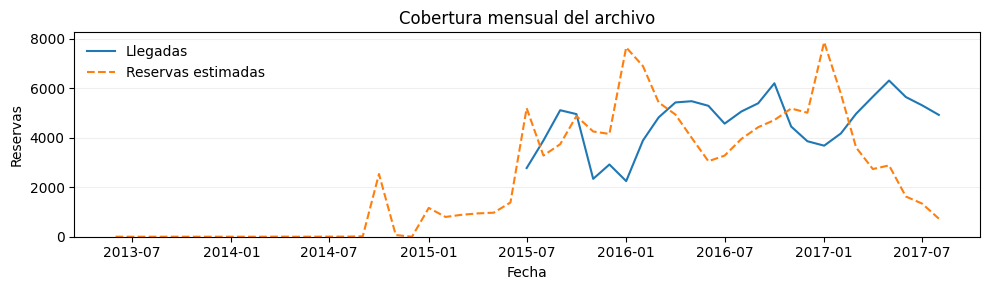

In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
for c, estilo, etiqueta in [('llegada', '-', 'Llegadas'), ('reserva_estimada', '--', 'Reservas estimadas')]:
    mensual = fechas[c].value_counts().sort_index().resample('MS').sum()
    ax.plot(mensual.index, mensual.values, estilo, label=etiqueta)
ax.set(title='Cobertura mensual del archivo', xlabel='Fecha', ylabel='Reservas', ylim=(0, None))
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()


Las llegadas van del **01/07/2015 al 31/08/2017**, pero las reservas estimadas empiezan en 2013.
El archivo está delimitado por llegadas: no contiene todas las reservas creadas en ese periodo.
La caída al final del gráfico no demuestra una caída de demanda.

### 3.4. Incoherencias y decisiones
Marcamos ceros, negativos, extremos y problemas de fechas. Los límites de ADR, huéspedes y noches
son alertas de revisión, no reglas para eliminar datos. La comparación estado/target solo comprueba la etiqueta.


In [7]:
numericas = df.select_dtypes(include='number')
conteos = [c for c in numericas if c not in ['adr', 'agent', 'company']]
target_por_estado = df['reservation_status'].map({'Canceled': 1, 'No-Show': 1, 'Check-Out': 0})
alertas = pd.DataFrame({
    'target_invalido': ~df[TARGET].isin([0, 1]),
    'huespedes_cero': huespedes_auditoria.eq(0),
    'huespedes_desconocidos': huespedes_auditoria.isna(),
    'adultos_cero': df['adults'].eq(0),
    'noches_cero': noches_auditoria.eq(0),
    'conteo_negativo': df[conteos].lt(0).any(axis=1),
    'conteo_fraccionario': df[conteos].mod(1).ne(0).where(df[conteos].notna(), False).any(axis=1),
    'infinito_numerico': numericas.isin([float('inf'), -float('inf')]).any(axis=1),
    'adr_negativo': df['adr'].lt(0),
    'adr_cero': df['adr'].eq(0),
    'adr_extremo': df['adr'].gt(ADR_ALERTA_EUR),
    'grupo_grande': huespedes_auditoria.gt(HUESPEDES_ALERTA),
    'estancia_larga': noches_auditoria.gt(NOCHES_ALERTA)
}, index=df.index)


In [8]:
alertas['fecha_invalida'] = fechas.isna().any(axis=1)
alertas['estado_anterior_reserva'] = fecha_estado.lt(fecha_reserva_est)
alertas['reserva_posterior_llegada'] = fecha_reserva_est.gt(fecha_llegada)
alertas['semana_fuera_rango'] = ~df['arrival_date_week_number'].between(1, 53)
alertas['repetidor_no_binario'] = ~df['is_repeated_guest'].isin([0, 1])
alertas['estado_target_incoherente'] = target_por_estado.isna() | target_por_estado.ne(df[TARGET])
alertas['checkout_antes_llegada'] = df['reservation_status'].eq('Check-Out') & fecha_estado.lt(fecha_llegada)
display(alertas.sum().loc[lambda s: s > 0].rename('filas señaladas').to_frame())


,filas señaladas
huespedes_cero,180
huespedes_desconocidos,4
adultos_cero,403
noches_cero,715
adr_negativo,1
adr_cero,1959
adr_extremo,1
grupo_grande,14
estancia_larga,24


**Lectura:** 180 reservas sin huéspedes, 715 sin noches y dos alertas de ADR (−6,38 € y 5.400 €).
No aparecen fechas inválidas ni incoherencias entre estado y target; `No-Show` corresponde a `is_canceled = 1`.
Las alertas pueden solaparse.

| Problema | Decisión y motivo | Impacto |
|---|---|---|
| Duplicados | Conservar: no hay ID que permita distinguir errores de reservas iguales. | 0 filas eliminadas |
| Nulos | Conservar: revisar su significado por variable; imputar después solo con entrenamiento. | 4 columnas, 0 valores sustituidos |
| Ceros y extremos | Marcar: pueden ser usos diurnos, cortesías, grupos o errores. | 0 filas eliminadas |
| Cronología o etiqueta inválida | Apartar si aparece: impediría una partición fiable. | 0 filas en este archivo |


## 4. Disponibilidad de variables y partición temporal
### 4.1. Qué variables usar
El artículo original sitúa parte de los valores en el día anterior a la llegada, **no al reservar**.
Se excluyen 13 campos por fuga directa o disponibilidad dudosa. Los 18 restantes son provisionales:
su valor inicial no está acreditado, salvo el contexto del establecimiento.

`country` y `company` se excluyen, por lo que sus nulos no requieren tratamiento para el modelo.
`adr` se incluye bajo el supuesto explícito de que aproxima la tarifa conocida al reservar.
Puede aportar información predictiva, pero también introducir fuga si recoge cambios posteriores.
No se realizó un análisis de sensibilidad sin `adr`; su disponibilidad inicial queda como limitación explícita.

El diccionario y la auditoría se reúnen aquí para evitar repetir definiciones.
Las decisiones no se basan en el rendimiento del test.


<details>
<summary><strong>Consultar diccionario y auditoría de las 32 variables</strong></summary>

<table style="width:100%;table-layout:fixed"><colgroup><col style="width:24%"><col style="width:27%"><col style="width:18%"><col style="width:8%"><col style="width:23%"></colgroup><thead><tr><th>Variable</th><th>Significado</th><th>Disponibilidad al reservar</th><th>Riesgo</th><th>Decisión y motivo</th></tr></thead><tbody><tr><td>hotel</td><td>Tipo de establecimiento: Resort Hotel o City Hotel.</td><td>Al reservar</td><td>Bajo</td><td>Incluir: establecimiento elegido.</td></tr><tr><td>is_canceled</td><td>1 = reserva cancelada, 0 = no cancelada</td><td>Posterior</td><td>Directo</td><td>Solo etiqueta, nunca predictor.</td></tr><tr><td>lead_time</td><td>Antelación en días entre registro de la reserva y llegada.</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>arrival_date_year</td><td>Año de llegada</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>arrival_date_month</td><td>Mes de llegada</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>arrival_date_week_number</td><td>Semana del año de llegada</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>arrival_date_day_of_month</td><td>Día del mes de llegada</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>stays_in_weekend_nights</td><td>Número de noches de fin de semana reservadas o realizadas.</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>stays_in_week_nights</td><td>Número de noches entre semana reservadas o realizadas.</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>adults</td><td>Número de adultos</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>children</td><td>Número de niños</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>babies</td><td>Número de bebés</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>meal</td><td>Régimen alimenticio: SC/Undefined = sin paquete; BB = solo desayuno; HB = media pensión; FB = pensión completa</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>country</td><td>País de origen registrado; su exactitud al reservar no está garantizada.</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Puede completarse/corregirse al llegar; disponibilidad no verificada.</td></tr><tr><td>market_segment</td><td>Segmento de mercado. TA = Travel Agents, TO = Tour Operators</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>distribution_channel</td><td>Canal de distribución de la reserva. TA = Travel Agents, TO = Tour Operators</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>is_repeated_guest</td><td>1 = cliente repetidor, 0 = primera vez</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Vinculación de perfil sin fecha de cálculo verificable.</td></tr><tr><td>previous_cancellations</td><td>Número de cancelaciones previas del cliente</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Resultados de reservas previas sin fecha de conocimiento.</td></tr><tr><td>previous_bookings_not_canceled</td><td>Número de reservas previas no canceladas del cliente</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Resultados previos pueden madurar después del alta actual.</td></tr><tr><td>reserved_room_type</td><td>Código del tipo de habitación reservada (anonimizado)</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>assigned_room_type</td><td>Código del tipo de habitación asignada (puede diferir de la reservada por overbooking o petición del cliente)</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Asignación operativa; no se prueba que exista al reservar.</td></tr><tr><td>booking_changes</td><td>Número de modificaciones realizadas sobre la reserva hasta check-in o cancelación</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Acumula modificaciones hasta llegada o cancelación.</td></tr><tr><td>deposit_type</td><td>Depósito realizado: No Deposit = sin depósito; Non Refund = depósito por el total de la estancia; Refundable = depósito parcial reembolsable</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Depósito realizado; no consta momento ni política inicial.</td></tr><tr><td>agent</td><td>ID de la agencia de viajes que realizó la reserva (anonimizado)</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>company</td><td>ID de la empresa responsable de la reserva o del pago (anonimizado)</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Responsable de reserva/pago; no se acredita asignación inicial.</td></tr><tr><td>days_in_waiting_list</td><td>Días que la reserva estuvo en lista de espera antes de confirmarse</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Espera acumulada; puede completarse tras el registro.</td></tr><tr><td>customer_type</td><td>Tipo de reserva: Contract = con contrato; Group = grupo; Transient = individual sin contrato; Transient-party = individual asociado a otra reserva transient</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Provisional: requiere confirmar el valor inicial.</td></tr><tr><td>adr</td><td>Average Daily Rate: precio medio por noche (€)</td><td>Inicial plausible; versión no verificada</td><td>Medio</td><td>Incluir provisionalmente: asumimos que aproxima la tarifa conocida al reservar.</td></tr><tr><td>required_car_parking_spaces</td><td>Plazas de aparcamiento solicitadas por el cliente</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: La solicitud puede añadirse después; falta historia.</td></tr><tr><td>total_of_special_requests</td><td>Número de peticiones especiales del cliente (ej. cama doble, piso alto)</td><td>Posterior / no verificada</td><td>Alto</td><td>Excluir: Peticiones acumuladas; falta instantánea inicial.</td></tr><tr><td>reservation_status</td><td>Último estado registrado: Canceled, Check-Out o No-Show.</td><td>Posterior / no verificada</td><td>Directo</td><td>Excluir: Resultado final: fuga directa.</td></tr><tr><td>reservation_status_date</td><td>Fecha en que se estableció el último estado registrado.</td><td>Posterior / no verificada</td><td>Directo</td><td>Excluir: Fecha del resultado; solo auditoría de maduración.</td></tr></tbody></table>
</details>


In [ ]:
#Se conservan en df para auditar, pero no entrarán en el modelo.
columnas_excluidas = [
    'reservation_status', 'reservation_status_date', 'assigned_room_type', 'booking_changes',
    'days_in_waiting_list', 'deposit_type', 'required_car_parking_spaces',
    'total_of_special_requests', 'country', 'company', 'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled'
]
predictoras = df.columns.drop(columnas_excluidas + [TARGET]).tolist()
print(f'{len(predictoras)} predictores provisionales; {len(columnas_excluidas)} columnas excluidas.')


18 predictores provisionales; 13 columnas excluidas.


### 4.2. Partición temporal
Usamos la **fecha estimada de reserva**: ordenar por llegada mezclaría solicitudes creadas en momentos distintos.
Es una aproximación porque no tenemos la fecha real de alta ni el historial de modificaciones.

Los cortes **01/07/2016** y **01/01/2017** dejan historia para entrenar, un semestre de validación y el último año
parcial para test. Se eligen por calendario y cobertura, no por rendimiento.

La partición inicial conserva las cohortes por fecha de reserva. En el modelado se añade una purga de madurez:
una fila solo ajusta el modelo si su **salida prevista** es anterior al periodo evaluado. Así evitamos utilizar
resultados que todavía no podían conocerse y no seleccionamos por la fecha real de cancelación, que depende del target.
Esta regla actúa como separación temporal; no se añade un margen arbitrario.

La salida prevista también es aproximada y no recoge cambios posteriores. Mejora la disponibilidad de etiquetas,
pero no sustituye un registro histórico de cuándo quedó consolidado cada resultado.

| Conjunto | Fecha estimada de reserva | Uso |
|---|---|---|
| Entrenamiento | Antes del 01/07/2016 | Ajustar con etiquetas maduras antes de cada corte |
| Validación | Del 01/07/2016 al 31/12/2016 | Comparar una vez los candidatos ya fijados |
| Test | Desde el 01/01/2017 | Evaluación final una vez cerradas las decisiones |


In [10]:
mascaras = {
    'entrenamiento': fecha_reserva_est < INICIO_VALIDACION,
    'validación': (fecha_reserva_est >= INICIO_VALIDACION) & (fecha_reserva_est < INICIO_TEST),
    'test': fecha_reserva_est >= INICIO_TEST
}


In [11]:
particion = pd.Series(index=df.index, dtype='string', name='particion')
for nombre, mascara in mascaras.items():
    particion.loc[mascara] = nombre
display(particion.value_counts().rename('filas').to_frame())


,filas
particion,
entrenamiento,66253
validación,26572
test,26565


### 4.3. Conjuntos preparados
Separamos predictores y etiquetas sin imputar, escalar ni entrenar. Las fechas auxiliares quedan fuera de `X`.
`adr` todavía conserva todos sus valores: su tratamiento se definirá después usando solo entrenamiento.
La tabla resume tamaños, fechas, proporción del dataset y cancelaciones de entrenamiento y validación.

In [12]:
indices = {nombre: df.index[mascara] for nombre, mascara in mascaras.items()}
X_train = df.loc[indices['entrenamiento'], predictoras].copy()
y_train = df.loc[indices['entrenamiento'], TARGET].copy()
X_valid = df.loc[indices['validación'], predictoras].copy()
y_valid = df.loc[indices['validación'], TARGET].copy()
X_test = df.loc[indices['test'], predictoras].copy()
y_test = df.loc[indices['test'], TARGET].copy()


In [13]:
tabla_particiones = pd.DataFrame([
    {
        'conjunto': nombre,
        'fecha_inicio_reserva': fecha_reserva_est.loc[idx].min().date(),
        'fecha_fin_reserva': fecha_reserva_est.loc[idx].max().date(),
        'reservas': len(idx),
        'cancelaciones': (pd.NA if nombre == 'test' else int(df.loc[idx, TARGET].sum())),
        'tasa_cancelacion (%)': (pd.NA if nombre == 'test' else 100 * df.loc[idx, TARGET].mean()),
        'porcentaje_dataset (%)': 100 * len(idx) / len(df)
    }
    for nombre, idx in indices.items()
]).set_index('conjunto')
display(tabla_particiones.round(2))

,fecha_inicio_reserva,fecha_fin_reserva,reservas,cancelaciones,tasa_cancelacion (%),porcentaje_dataset (%)
conjunto,,,,,,
entrenamiento,2013-06-24,2016-06-30,66253,25817,38.967292,55.49
validación,2016-07-01,2016-12-31,26572,10005,37.652416,22.26
test,2017-01-01,2017-08-31,26565,<NA>,<NA>,22.25


**Resultado:** 66.253 reservas de entrenamiento, 26.572 de validación y 26.565 de test. Las fechas corresponden a la reserva estimada, que es la variable utilizada para el corte temporal. La tasa de cancelación del test permanece sin consultar hasta la evaluación final.

## 5. EDA con foco de negocio

Todo el análisis de esta sección utiliza únicamente entrenamiento. Se excluyen 457 registros del ámbito
analítico porque tienen `children` nulo, cero huéspedes o cero noches. Los casos pueden solaparse.
Los valores de `adr` se conservan en esta sección para estudiar su distribución antes de decidir el tratamiento.


In [14]:
train_eda = df.loc[indices['entrenamiento']].copy()
train_eda['fecha_llegada'] = fecha_llegada.loc[train_eda.index]
train_eda['total_guests'] = train_eda[['adults', 'children', 'babies']].sum(axis=1, min_count=3)
train_eda['total_nights'] = train_eda['stays_in_weekend_nights'] + train_eda['stays_in_week_nights']

fuera_ambito = (
    train_eda['children'].isna()
    | train_eda['total_guests'].eq(0)
    | train_eda['total_nights'].eq(0)
)
train_eda = train_eda.loc[~fuera_ambito].copy()

def resumen_cancelacion(datos, variable):
    tabla = datos.groupby(variable, dropna=False, observed=False)[TARGET].agg(
        reservas='size', canceladas='sum', tasa_cancelacion='mean'
    )
    tabla['tasa_cancelacion'] = (100 * tabla['tasa_cancelacion']).round(1)
    return tabla

print(f'Población EDA: {len(train_eda):,} reservas de entrenamiento.')


Población EDA: 65,796 reservas de entrenamiento.


### 5.1. Hotel
**Pregunta:** ¿el riesgo observado y el volumen de cancelaciones difieren entre los dos hoteles?


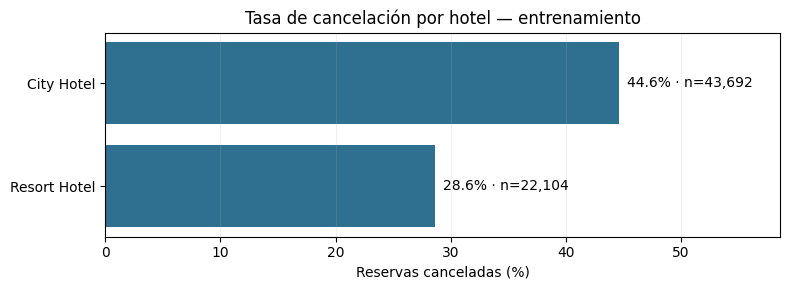

In [15]:
tabla_hotel = resumen_cancelacion(train_eda, 'hotel').sort_values('tasa_cancelacion')

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(tabla_hotel.index, tabla_hotel['tasa_cancelacion'], color='#2F6F8F')
for posicion, (_, fila) in enumerate(tabla_hotel.iterrows()):
    ax.text(fila['tasa_cancelacion'] + 0.7, posicion,
            f"{fila['tasa_cancelacion']:.1f}% · n={int(fila['reservas']):,}", va='center')
ax.set(title='Tasa de cancelación por hotel — entrenamiento', xlabel='Reservas canceladas (%)', ylabel='')
ax.set_xlim(0, tabla_hotel['tasa_cancelacion'].max() + 14)
ax.grid(axis='x', alpha=.2)
fig.tight_layout()
plt.show()


El **City Hotel** registra un 44,6% de cancelación sobre 43.692 reservas, frente al 28,6%
del **Resort Hotel** sobre 22.104. Es una asociación agregada: también puede reflejar diferencias
de canal, cliente, antelación o temporada.

**Propuesta a evaluar:** controlar el rendimiento y la calibración por hotel y valorar umbrales operativos
distintos solo si la validación confirma que la diferencia persiste dentro de perfiles comparables.


### 5.2. Evolución mensual
**Pregunta:** ¿cómo cambia la tasa de cancelación por mes y qué parte puede atribuirse realmente
a estacionalidad?


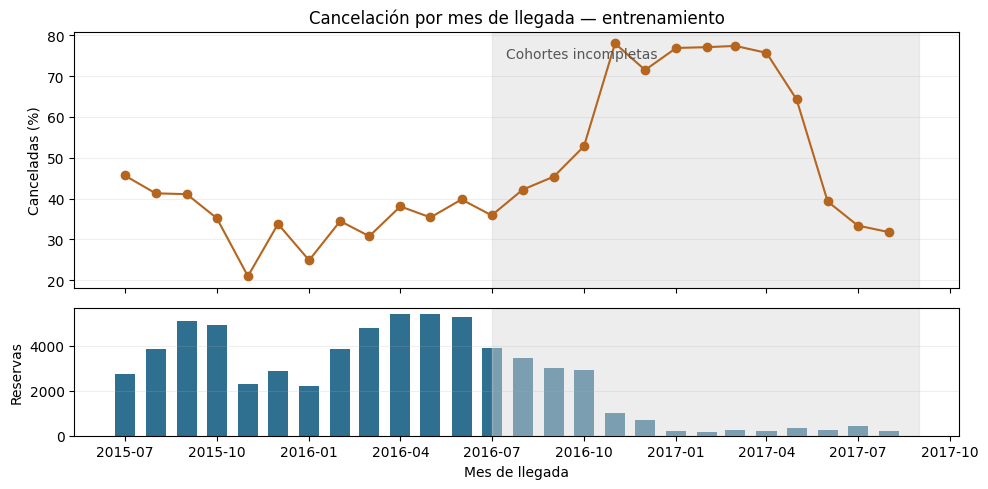

In [16]:
train_eda['periodo_llegada'] = train_eda['fecha_llegada'].dt.to_period('M')
tabla_mensual = resumen_cancelacion(train_eda, 'periodo_llegada').sort_index()
eje_fechas = tabla_mensual.index.to_timestamp()

fig, (ax_tasa, ax_n) = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                                    gridspec_kw={'height_ratios': [2, 1]})
ax_tasa.plot(eje_fechas, tabla_mensual['tasa_cancelacion'], marker='o', color='#B5651D')
ax_n.bar(eje_fechas, tabla_mensual['reservas'], width=20, color='#2F6F8F')
for ax in (ax_tasa, ax_n):
    ax.axvspan(INICIO_VALIDACION, eje_fechas.max() + pd.offsets.MonthEnd(), color='#D9D9D9', alpha=.45)
    ax.grid(axis='y', alpha=.2)
ax_tasa.set(title='Cancelación por mes de llegada — entrenamiento', ylabel='Canceladas (%)')
ax_tasa.text(pd.Timestamp('2016-07-15'), ax_tasa.get_ylim()[1] * .92, 'Cohortes incompletas', color='#555555')
ax_n.set(xlabel='Mes de llegada', ylabel='Reservas')
fig.tight_layout()
plt.show()


Hasta junio de 2016 las cohortes de llegada están completas dentro del corte de entrenamiento.
En ese tramo la tasa oscila entre el 21,0% (noviembre de 2015) y el 45,7% (julio de 2015).
Solo hay una observación completa de cada mes del calendario, por lo que no podemos separar con solidez
estacionalidad y diferencias entre años. Desde julio de 2016 faltan reservas creadas después del corte;
sus tasas elevadas no deben interpretarse como una subida real.

**Propuesta a evaluar:** mantener seguimiento mensual y comparar el mismo mes en varios años cuando haya
cohortes completas; no definir políticas estacionales con los meses sombreados.


### 5.3. Canal y segmento
**Pregunta:** ¿por qué vías llegan las reservas con mayor cancelación y qué tipo de demanda representan?

`distribution_channel` describe la vía operativa por la que llega la reserva; `market_segment` clasifica
el tipo comercial de demanda. Una reserva puede llegar por TA/TO y pertenecer, por ejemplo, al segmento Groups.


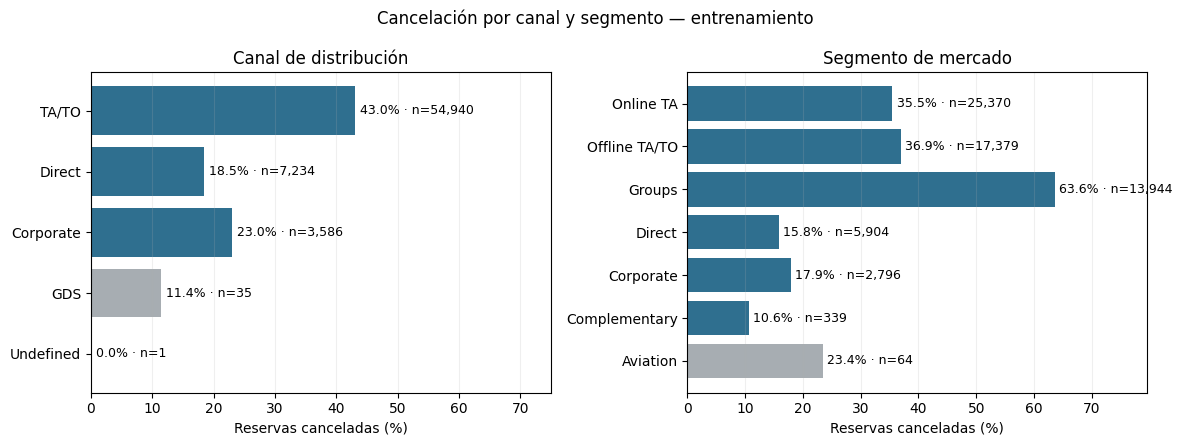

In [17]:
tabla_canal = resumen_cancelacion(train_eda, 'distribution_channel').sort_values('reservas')
tabla_segmento = resumen_cancelacion(train_eda, 'market_segment').sort_values('reservas')

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, tabla, titulo in [
    (ejes[0], tabla_canal, 'Canal de distribución'),
    (ejes[1], tabla_segmento, 'Segmento de mercado')
]:
    colores = ['#A7ADB2' if n < 100 else '#2F6F8F' for n in tabla['reservas']]
    ax.barh(tabla.index, tabla['tasa_cancelacion'], color=colores)
    for posicion, (_, fila) in enumerate(tabla.iterrows()):
        ax.text(fila['tasa_cancelacion'] + .8, posicion,
                f"{fila['tasa_cancelacion']:.1f}% · n={int(fila['reservas']):,}", va='center', fontsize=9)
    ax.set(title=titulo, xlabel='Reservas canceladas (%)', ylabel='')
    ax.set_xlim(0, max(75, tabla['tasa_cancelacion'].max() + 16))
    ax.grid(axis='x', alpha=.2)
fig.suptitle('Cancelación por canal y segmento — entrenamiento')
fig.tight_layout()
plt.show()


TA/TO concentra 54.940 reservas y una tasa del 43,0%, frente al 18,5% del canal directo y el 23,0%
del corporativo. GDS (35 reservas) y Undefined (1) son demasiado pequeños para extraer conclusiones.
Por segmento, **Groups** alcanza el 63,6% sobre 13.944 reservas; Online TA y Offline TA/TO se sitúan
en 35,5% y 36,9%. Las diferencias no prueban que el canal o el segmento causen la cancelación.

**Propuesta a evaluar:** priorizar el seguimiento de reservas TA/TO y de grupos, y comprobar por socio,
hotel y antelación si una política específica mejora resultados sin penalizar reservas de bajo riesgo.


### 5.4. Antelación (`lead_time`)
**Pregunta:** ¿cómo cambia la cancelación según el tiempo entre la reserva y la llegada?


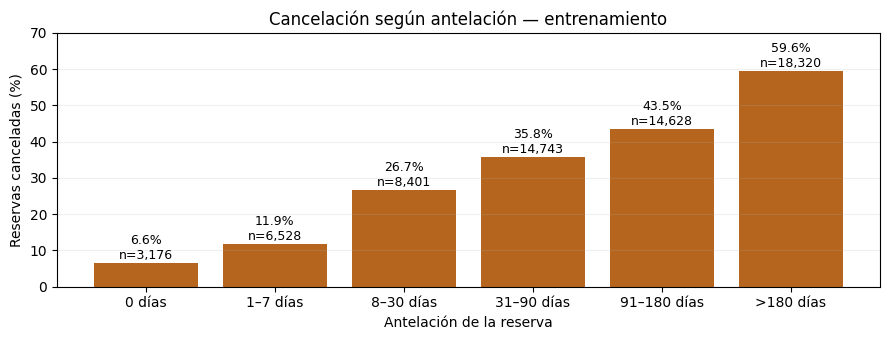

In [18]:
limites_lead = [-1, 0, 7, 30, 90, 180, float('inf')]
etiquetas_lead = ['0 días', '1–7 días', '8–30 días', '31–90 días', '91–180 días', '>180 días']
train_eda['tramo_lead_time'] = pd.cut(
    train_eda['lead_time'], bins=limites_lead, labels=etiquetas_lead
)
tabla_lead = resumen_cancelacion(train_eda, 'tramo_lead_time').reindex(etiquetas_lead)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(tabla_lead.index, tabla_lead['tasa_cancelacion'], color='#B5651D')
for posicion, (_, fila) in enumerate(tabla_lead.iterrows()):
    ax.text(posicion, fila['tasa_cancelacion'] + 1,
            f"{fila['tasa_cancelacion']:.1f}%\nn={int(fila['reservas']):,}", ha='center', fontsize=9)
ax.set(title='Cancelación según antelación — entrenamiento', xlabel='Antelación de la reserva',
       ylabel='Reservas canceladas (%)', ylim=(0, 70))
ax.grid(axis='y', alpha=.2)
fig.tight_layout()
plt.show()


La tasa aumenta de forma progresiva: 6,6% en reservas del mismo día, 35,8% entre 31 y 90 días,
43,5% entre 91 y 180 días y 59,6% por encima de 180 días. Es el patrón descriptivo más claro del EDA,
pero puede estar relacionado con el canal, el hotel o el tipo de cliente.

**Propuesta a evaluar:** utilizar niveles de seguimiento por antelación y probar comunicaciones o condiciones
específicas para reservas de más de 90 días, midiendo su efecto antes de convertirlas en política general.


### 5.5. ADR
**Pregunta:** ¿difieren las tarifas de las reservas canceladas y no canceladas, y cuánto influyen
los valores extremos en la comparación?


,reservas,media,mediana,p95,p99,máximo
is_canceled,,,,,,
No cancelada,40010,92.75,87.67,170.0,223.00,508.0
Cancelada,25786,93.90,89.00,170.0,222.08,5400.0


,límite (€),reservas superiores,porcentaje
"Regla 1,5 × IQR",188.25,2014,3.09
Percentil 99,223.58,651,1.00
"Percentil 99,5",243.00,325,0.50


Vista hasta 243.00 €: omite 325 tarifas positivas (0.50%). ADR no positivo: 711; máximo: 5,400.00 €.


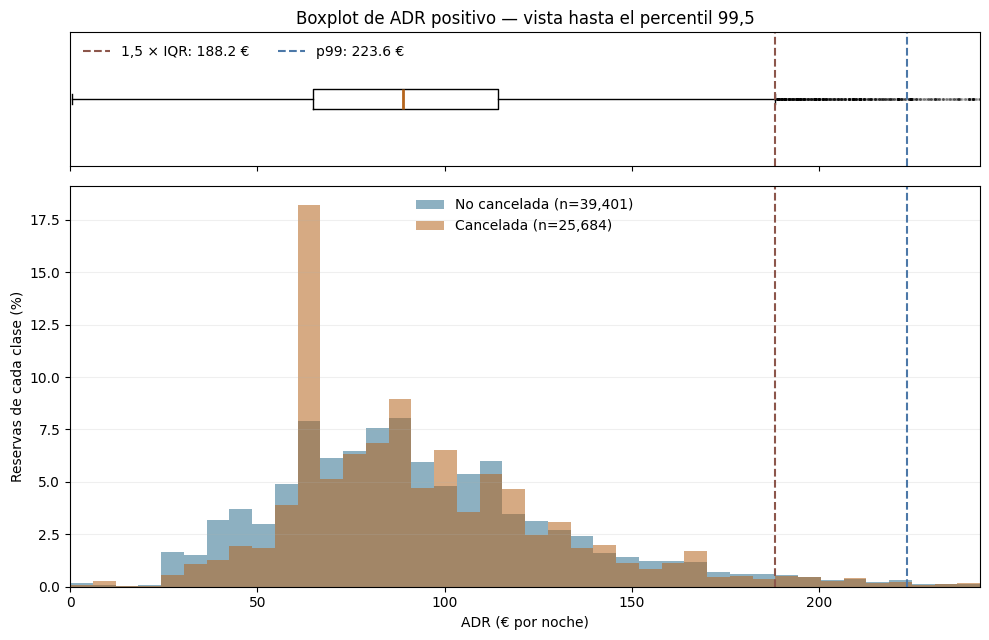

In [19]:
tabla_adr = train_eda.groupby(TARGET)['adr'].agg(
    reservas='size', media='mean', mediana='median',
    p95=lambda serie: serie.quantile(.95),
    p99=lambda serie: serie.quantile(.99), máximo='max'
).rename(index={0: 'No cancelada', 1: 'Cancelada'}).round(2)
display(tabla_adr)

adr_positivo = train_eda.loc[train_eda['adr'] > 0, 'adr']
q1, mediana, q3 = adr_positivo.quantile([.25, .50, .75])
limite_iqr = q3 + 1.5 * (q3 - q1)
p99 = adr_positivo.quantile(.99)
p995 = adr_positivo.quantile(.995)

criterios_adr = pd.DataFrame({
    'límite (€)': [limite_iqr, p99, p995],
    'reservas superiores': [
        adr_positivo.gt(limite_iqr).sum(),
        adr_positivo.gt(p99).sum(),
        adr_positivo.gt(p995).sum()
    ]
}, index=['Regla 1,5 × IQR', 'Percentil 99', 'Percentil 99,5'])
criterios_adr['porcentaje'] = (
    100 * criterios_adr['reservas superiores'] / len(adr_positivo)
).round(2)
display(criterios_adr.round({'límite (€)': 2}))

fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 6.5), sharex=True,
    gridspec_kw={'height_ratios': [1, 3]}
)
ax_box.boxplot(
    adr_positivo, vert=False, showfliers=True,
    flierprops={'marker': '.', 'markersize': 2, 'alpha': .10},
    medianprops={'color': '#B5651D', 'linewidth': 2}
)
for limite, color, etiqueta in [
    (limite_iqr, '#8C564B', '1,5 × IQR'),
    (p99, '#4C78A8', 'p99')
]:
    ax_box.axvline(limite, color=color, linestyle='--', label=f'{etiqueta}: {limite:.1f} €')
    ax_hist.axvline(limite, color=color, linestyle='--')
ax_box.set(title='Boxplot de ADR positivo — vista hasta el percentil 99,5', yticks=[])
ax_box.legend(frameon=False, ncol=2, loc='upper left')

for clase, etiqueta, color in [(0, 'No cancelada', '#2F6F8F'), (1, 'Cancelada', '#B5651D')]:
    valores = train_eda.loc[(train_eda[TARGET] == clase) & train_eda['adr'].gt(0), 'adr']
    visibles = valores[valores <= p995]
    ax_hist.hist(
        visibles, bins=40, range=(0, p995), weights=pd.Series(100 / len(valores), index=visibles.index),
        alpha=.55, label=f'{etiqueta} (n={len(valores):,})', color=color
    )
ax_hist.set(xlabel='ADR (€ por noche)', ylabel='Reservas de cada clase (%)')
ax_hist.legend(frameon=False)
ax_hist.grid(axis='y', alpha=.2)
ax_hist.set_xlim(0, p995)
fig.tight_layout()

omitidas = adr_positivo.gt(p995).sum()
print(
    f'Vista hasta {p995:.2f} €: omite {omitidas:,} tarifas positivas '
    f'({100 * omitidas / len(adr_positivo):.2f}%). '
    f'ADR no positivo: {train_eda["adr"].le(0).sum():,}; máximo: {train_eda["adr"].max():,.2f} €.'
)
plt.show()


El ADR medio es 92,75 € en no canceladas y 93,90 € en canceladas; las medianas son 87,67 € y 89,00 €.
La diferencia agregada es pequeña. El máximo de 5.400 € pertenece a una reserva cancelada y queda fuera de la
vista ampliada; la asociación no permite concluir que el precio cause la cancelación.

La regla de 1,5 × IQR marcaría como extremos 2.014 ADR positivos (3,09%), el percentil 99 marcaría 651 (1,00%)
y el percentil 99,5 marcaría 325 (0,50%). La elección define qué reservas quedan dentro del ámbito del modelo,
por lo que debe justificarse como decisión de negocio y calcularse solo con entrenamiento dentro de cada ajuste.


### Notas para la presentación

- El City Hotel presenta mayor cancelación agregada, pero puede reflejar distinta composición de reservas.
- TA/TO concentra volumen y riesgo; Groups destaca como segmento, que es un concepto distinto del canal.
- La antelación muestra el gradiente más consistente y ofrece una segmentación operativa sencilla para evaluar.
- ADR apenas separa las clases en promedio. Como referencia, 1,5 × IQR retiraría el 3,09%, p99 el 1,00% y p99,5 el 0,50% de las tarifas positivas.
- No puede afirmarse una estacionalidad estable: solo hay doce cohortes completas y los periodos posteriores están truncados.


## 6. Ingeniería de variables

Se proponen seis variables sencillas, calculables con información solicitada al reservar.

| Variable nueva | Fórmula y origen | Justificación de negocio | Disponibilidad y cautelas |
|---|---|---|---|
| `total_guests` | `adults + children + babies` | Resume el tamaño del grupo. | Disponible si la composición inicial es correcta. |
| `total_nights` | `stays_in_weekend_nights + stays_in_week_nights` | Representa la duración total solicitada. | Puede cambiar después de reservar. |
| `has_children` | 1 si `children + babies > 0` | Distingue reservas con menores sin crear categorías complejas. | Requiere `children` informado. |
| `weekend_share` | Noches de fin de semana / `total_nights` | Separa estancias orientadas al fin de semana de las laborales. | Se protege la división por cero. |
| `arrival_weekend` | 1 si la llegada es sábado o domingo | Resume el contexto operativo de la fecha de llegada. | Derivada de la llegada registrada. |
| `booking_month` | Mes de llegada menos `lead_time` | Recoge la temporada en que se realiza la reserva. | La fecha de reserva es estimada. |

Los agregados son redundantes con sus componentes. Se mantienen como candidatos porque expresan relaciones útiles,
pero la selección se hará con entrenamiento y validación. En un modelo lineal se revisará especialmente la convivencia
entre componentes y totales.


In [20]:
filas_modelo = (
    df['children'].notna()
    & huespedes_auditoria.gt(0)
    & noches_auditoria.gt(0)
)
X_train_base = X_train.loc[filas_modelo.loc[X_train.index]].copy()
y_train_fe = y_train.loc[X_train_base.index].copy()
X_valid_base = X_valid.loc[filas_modelo.loc[X_valid.index]].copy()
y_valid_fe = y_valid.loc[X_valid_base.index].copy()

def crear_variables(datos):
    resultado = datos.copy()
    resultado['total_guests'] = resultado[['adults', 'children', 'babies']].sum(axis=1)
    resultado['total_nights'] = resultado['stays_in_weekend_nights'] + resultado['stays_in_week_nights']
    resultado['has_children'] = (resultado['children'] + resultado['babies'] > 0).astype('int8')
    resultado['weekend_share'] = (
        resultado['stays_in_weekend_nights'] / resultado['total_nights']
    ).where(resultado['total_nights'] > 0)
    llegada = pd.to_datetime(pd.DataFrame({
        'year': resultado['arrival_date_year'],
        'month': resultado['arrival_date_month'].map(MESES),
        'day': resultado['arrival_date_day_of_month']
    }, index=resultado.index))
    reserva_estimada = llegada - pd.to_timedelta(resultado['lead_time'], unit='D')
    resultado['arrival_weekend'] = llegada.dt.dayofweek.ge(5).astype('int8')
    resultado['booking_month'] = reserva_estimada.dt.month
    return resultado

X_train_fe = crear_variables(X_train_base)
X_valid_fe = crear_variables(X_valid_base)


In [21]:
nuevas_variables = [
    'total_guests', 'total_nights', 'has_children',
    'weekend_share', 'arrival_weekend', 'booking_month'
]
display(pd.DataFrame({
    'conjunto': ['Entrenamiento', 'Validación'],
    'filas antes': [len(X_train), len(X_valid)],
    'filas preparadas': [len(X_train_fe), len(X_valid_fe)],
    'filas retiradas': [len(X_train) - len(X_train_fe), len(X_valid) - len(X_valid_fe)]
}).set_index('conjunto'))
display(X_train_fe[nuevas_variables].head())


,filas antes,filas preparadas,filas retiradas
conjunto,,,
Entrenamiento,66253,65796,457
Validación,26572,26356,216


,total_guests,total_nights,has_children,weekend_share,arrival_weekend,booking_month
2,1.0,1,0,0.0,0,6
3,1.0,1,0,0.0,0,6
4,2.0,2,0,0.0,0,6
5,2.0,2,0,0.0,0,6
6,2.0,2,0,0.0,0,7


Las transformaciones son deterministas y se han aplicado con la misma función a entrenamiento y validación.
El test permanece sin transformar; más adelante se aplicará la misma función una sola vez para la evaluación final.

La creación de estas variables no aprende estadísticas. La imputación, codificación, escalado, selección de variables
y límites de ADR sí deberán ajustarse dentro de entrenamiento y de cada partición de validación cruzada.
No se utiliza ninguna variable excluida ni información posterior al resultado de la reserva.


## 7. Preprocesamiento

El preprocesamiento se define según el significado de cada variable y se integra con el modelo para evitar
ajustes independientes. Antes de cada entrenamiento se conservan solo etiquetas maduras y se fija el ámbito de ADR: se excluyen valores
no positivos y los superiores al percentil 99 aprendido únicamente con el periodo de ajuste.

| Tipo | Tratamiento | Motivo |
|---|---|---|
| Numéricas | Mediana y `StandardScaler` | La mediana es resistente a extremos; el escalado es necesario para comparar coeficientes y regularizar la regresión. |
| Categóricas | Categoría explícita para nulos y `OneHotEncoder` | Un nulo no se interpreta como cero; se admiten niveles nuevos sin cambiar las columnas. |
| Binarias creadas | Moda, sin escalado | Conservan su interpretación 0/1. |
| `agent` | Categórica; niveles infrecuentes agrupados (umbral de 50 en la referencia logística y 20 en el modelo final) | Es un identificador de agencia, no una cantidad. Un nulo representa agencia ausente o desconocida. |

`company` continúa excluida. Los modelos de árboles que se prueben después no necesitarán escalado, aunque sí
un tratamiento coherente de nulos y categorías.


In [22]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

variables_categoricas = [
    'hotel', 'arrival_date_month', 'meal', 'market_segment',
    'distribution_channel', 'reserved_room_type', 'agent',
    'customer_type', 'booking_month'
]
variables_binarias = ['has_children', 'arrival_weekend']
variables_numericas = [c for c in X_train_fe.columns if c not in variables_categoricas + variables_binarias]

filas_maduras_train = salida_estimada.loc[X_train_fe.index] < INICIO_VALIDACION
X_train_maduro = X_train_fe.loc[filas_maduras_train].copy()
y_train_maduro = y_train_fe.loc[X_train_maduro.index].copy()
limite_adr = X_train_maduro.loc[X_train_maduro['adr'] > 0, 'adr'].quantile(.99)
ambito_train = X_train_maduro['adr'].gt(0) & X_train_maduro['adr'].le(limite_adr)
ambito_valid = X_valid_fe['adr'].gt(0) & X_valid_fe['adr'].le(limite_adr)

balance_train = y_train_maduro.loc[ambito_train].value_counts().sort_index().rename('reservas').to_frame()
balance_train['porcentaje'] = (100 * balance_train['reservas'] / balance_train['reservas'].sum()).round(1)
balance_train.index = ['No cancelada', 'Cancelada']
display(balance_train)
print(f'Ámbito ADR de entrenamiento maduro: 0 < ADR ≤ {limite_adr:.2f} €.')
print(f'Filas: {ambito_train.sum():,} entrenamiento; {ambito_valid.sum():,} validación.')


,reservas,porcentaje
No cancelada,29891,63.6
Cancelada,17115,36.4


Ámbito ADR de entrenamiento maduro: 0 < ADR ≤ 205.59 €.
Filas: 47,006 entrenamiento; 25,227 validación.


Los nulos numéricos futuros se imputarán con la mediana aprendida en entrenamiento. En las categóricas se crea
un nivel propio porque ausencia y valor cero no son equivalentes. `children` ya se trató al definir la población;
no se inventa un número de menores. El codificador agrupa niveles infrecuentes y dirige allí categorías nuevas
cuando existe ese grupo, manteniendo siempre la estructura aprendida.


In [23]:
def crear_pipeline_logistico(peso_clase=None, C=1.0, min_frequency=50):
    proceso_numerico = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escalado', StandardScaler())
    ])
    proceso_categorico = Pipeline([
        ('imputador', SimpleImputer(strategy='constant', fill_value=-1)),
        ('onehot', OneHotEncoder(
            handle_unknown='infrequent_if_exist',
            min_frequency=min_frequency,
            sparse_output=True
        ))
    ])
    preprocesamiento = ColumnTransformer([
        ('num', proceso_numerico, variables_numericas),
        ('cat', proceso_categorico, variables_categoricas),
        ('bin', SimpleImputer(strategy='most_frequent'), variables_binarias)
    ])
    return Pipeline([
        ('preprocesamiento', preprocesamiento),
        ('modelo', LogisticRegression(
            C=C, max_iter=1000, solver='liblinear',
            class_weight=peso_clase, random_state=SEMILLA
        ))
    ])


El imputador, el escalador, las categorías y la regresión se ajustan juntos. En validación solo se ejecuta
`predict_proba`: ningún componente vuelve a aprender. El umbral de ADR, al retirar filas y no solo transformar
columnas, se calcula explícitamente dentro de cada fold temporal.


## 8. Regresión logística de referencia

La regresión logística aporta una referencia rápida e interpretable. La métrica principal será **AUC-ROC**,
que evalúa si el modelo ordena las cancelaciones por encima de las no cancelaciones sin fijar todavía un umbral.
F1, precisión y recall se muestran con 0,5 únicamente como referencia.

Se usan tres folds temporales. En cada uno se purgan reservas cuya salida prevista todavía no ocurrió,
y el límite ADR y el preprocesamiento se aprenden de nuevo. Para mejorar el baseline se comparan cuatro niveles
de regularización, tres umbrales de agrupación de categorías poco frecuentes y el uso o no de pesos de clase.


In [24]:
folds_temporales = [
    ('2015-09-01', '2016-01-01'),
    ('2016-01-01', '2016-04-01'),
    ('2016-04-01', '2016-07-01')
]

folds_modelado = []
for numero_fold, (inicio_fold, fin_fold) in enumerate(folds_temporales, 1):
    inicio_fold, fin_fold = pd.Timestamp(inicio_fold), pd.Timestamp(fin_fold)
    fechas_train = fecha_reserva_est.loc[X_train_fe.index]
    idx_ajuste = X_train_fe.index[
        (fechas_train < inicio_fold) & (salida_estimada.loc[X_train_fe.index] < inicio_fold)
    ]
    idx_revision = X_train_fe.index[(fechas_train >= inicio_fold) & (fechas_train < fin_fold)]
    X_ajuste, y_ajuste = X_train_fe.loc[idx_ajuste], y_train_fe.loc[idx_ajuste]
    X_revision, y_revision = X_train_fe.loc[idx_revision], y_train_fe.loc[idx_revision]
    limite_fold = X_ajuste.loc[X_ajuste['adr'] > 0, 'adr'].quantile(.99)
    filas_ajuste = X_ajuste['adr'].gt(0) & X_ajuste['adr'].le(limite_fold)
    filas_revision = X_revision['adr'].gt(0) & X_revision['adr'].le(limite_fold)
    folds_modelado.append({
        'fold': numero_fold,
        'X_ajuste': X_ajuste.loc[filas_ajuste], 'y_ajuste': y_ajuste.loc[filas_ajuste],
        'X_revision': X_revision.loc[filas_revision], 'y_revision': y_revision.loc[filas_revision],
        'limite_adr': limite_fold
    })

display(pd.DataFrame([{
    'fold': fold['fold'], 'reservas de ajuste': len(fold['y_ajuste']),
    'reservas de revisión': len(fold['y_revision']),
    'cancelación revisión (%)': 100 * fold['y_revision'].mean(),
    'límite ADR (€)': fold['limite_adr']
} for fold in folds_modelado]).set_index('fold').round(1))

resultados_cv = []
for C in [.01, .1, 1, 10]:
    for frecuencia in [20, 50, 100]:
        for nombre, peso in [('Sin pesos', None), ('Pesos balanceados', 'balanced')]:
            for fold in folds_modelado:
                candidato = crear_pipeline_logistico(peso, C, frecuencia)
                candidato.fit(fold['X_ajuste'], fold['y_ajuste'])
                probabilidad = candidato.predict_proba(fold['X_revision'])[:, 1]
                prediccion = (probabilidad >= .5).astype(int)
                resultados_cv.append({
                    'modelo': nombre, 'C': C, 'frecuencia mínima': frecuencia,
                    'fold': fold['fold'],
                    'AUC-ROC': roc_auc_score(fold['y_revision'], probabilidad),
                    'F1': f1_score(fold['y_revision'], prediccion),
                    'Precision': precision_score(fold['y_revision'], prediccion, zero_division=0),
                    'Recall': recall_score(fold['y_revision'], prediccion)
                })

resultados_cv = pd.DataFrame(resultados_cv)
tabla_logistica = resultados_cv.groupby(
    ['modelo', 'C', 'frecuencia mínima'], as_index=False
).agg(
    AUC_ROC_media=('AUC-ROC', 'mean'), AUC_ROC_desviacion=('AUC-ROC', 'std'),
    F1_medio=('F1', 'mean'), Precision_media=('Precision', 'mean'),
    Recall_medio=('Recall', 'mean')
).sort_values('AUC_ROC_media', ascending=False)

resumen_cv = tabla_logistica.groupby('modelo', as_index=False).first().set_index('modelo')
mejor_logistico = tabla_logistica.iloc[0]
parametros_logisticos = {
    'peso_clase': None if mejor_logistico['modelo'] == 'Sin pesos' else 'balanced',
    'C': float(mejor_logistico['C']),
    'min_frequency': int(mejor_logistico['frecuencia mínima'])
}
display(resumen_cv.round(3))
print(f'Configuración seleccionada: {parametros_logisticos}')


,reservas de ajuste,reservas de revisión,cancelación revisión (%),límite ADR (€)
fold,,,,
1,6058,16614,35.6,241.0
2,20624,19502,33.6,214.0
3,31267,11293,36.2,210.0


,C,frecuencia mínima,AUC_ROC_media,AUC_ROC_desviacion,F1_medio,Precision_media,Recall_medio
modelo,,,,,,,
Pesos balanceados,0.1,20,0.694,0.050,0.573,0.505,0.669
Sin pesos,0.1,20,0.694,0.049,0.515,0.535,0.516


Configuración seleccionada: {'peso_clase': None, 'C': 0.1, 'min_frequency': 20}


Sin pesos alcanza AUC-ROC media 0.694 y con pesos 0.694. Se selecciona la variante **sin pesos**, con C=0.1 y agrupación desde 20 reservas. F1, precisión y recall siguen referidos a 0,5.


,valor,umbral
AUC-ROC,0.754,No aplica
F1,0.499,"0,5"
Precision,0.728,"0,5"
Recall,0.380,"0,5"


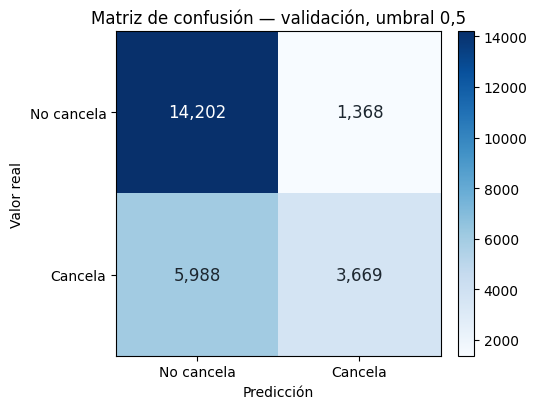

In [25]:
modelo_logistico = crear_pipeline_logistico(**parametros_logisticos)
modelo_logistico.fit(X_train_maduro.loc[ambito_train], y_train_maduro.loc[ambito_train])
y_valid_ambito = y_valid_fe.loc[ambito_valid]
probabilidad_valid = modelo_logistico.predict_proba(X_valid_fe.loc[ambito_valid])[:, 1]
prediccion_valid = (probabilidad_valid >= .5).astype(int)
metricas_validacion = pd.DataFrame({
    'valor': [roc_auc_score(y_valid_ambito, probabilidad_valid),
              f1_score(y_valid_ambito, prediccion_valid),
              precision_score(y_valid_ambito, prediccion_valid, zero_division=0),
              recall_score(y_valid_ambito, prediccion_valid)],
    'umbral': ['No aplica', '0,5', '0,5', '0,5']
}, index=['AUC-ROC', 'F1', 'Precision', 'Recall'])
display(metricas_validacion.round(3))

matriz = confusion_matrix(y_valid_ambito, prediccion_valid)
fig, ax = plt.subplots(figsize=(5.5, 4.2))
imagen_matriz = ax.imshow(matriz, cmap='Blues')
for fila in range(2):
    for columna in range(2):
        ax.text(columna, fila, f'{matriz[fila, columna]:,}', ha='center', va='center',
                color='white' if matriz[fila, columna] > matriz.max() / 2 else '#1d2730', fontsize=12)
ax.set(title='Matriz de confusión — validación, umbral 0,5', xlabel='Predicción', ylabel='Valor real',
       xticks=[0, 1], yticks=[0, 1], xticklabels=['No cancela', 'Cancela'],
       yticklabels=['No cancela', 'Cancela'])
fig.colorbar(imagen_matriz, ax=ax, fraction=.046, pad=.04)
fig.tight_layout()
plt.show()


En validación de desarrollo, el baseline alcanza **AUC-ROC 0.754**. Con umbral 0,5 obtiene F1 0.499, precisión 0.728 y recall 0.380. La matriz contiene 14,202 verdaderos negativos, 1,368 falsos positivos, 5,988 falsos negativos y 3,669 verdaderos positivos.

El umbral 0,5 sigue siendo solo una referencia y se revisará según los costes de negocio.


In [26]:
nombres_modelo = modelo_logistico.named_steps['preprocesamiento'].get_feature_names_out()
coeficientes = pd.DataFrame({
    'variable': nombres_modelo,
    'coeficiente': modelo_logistico.named_steps['modelo'].coef_[0]
})
coeficientes['magnitud'] = coeficientes['coeficiente'].abs()
coeficientes_relevantes = (
    coeficientes.loc[
        ~coeficientes['variable'].str.contains('agent_')
        & ~coeficientes['variable'].str.contains('infrequent_sklearn')
    ]
    .nlargest(12, 'magnitud')
    .drop(columns='magnitud')
)
display(coeficientes_relevantes.round(3).set_index('variable'))


,coeficiente
variable,
cat__market_segment_Groups,1.709
cat__customer_type_Transient-Party,-1.267
cat__hotel_Resort Hotel,-1.020
cat__customer_type_Transient,0.835
cat__market_segment_Online TA,-0.811
num__lead_time,0.802
cat__meal_FB,0.762
cat__meal_Undefined,-0.583
cat__market_segment_Direct,-0.558


La tabla muestra las asociaciones de mayor magnitud fuera de agent. Las numéricas están estandarizadas; los coeficientes categóricos dependen de la codificación y la regularización. Los identificadores de agencia pueden capturar composición de cartera o periodos concretos y no deben interpretarse como efectos causales.

La configuración elegida por AUC-ROC usa C=0.1, frecuencia mínima 20 y sin pesos. El umbral 0,5 sigue siendo provisional.


## 9. Modelos alternativos y optimización

Se amplía la referencia logística con cuatro familias: **árbol de decisión**, **Random Forest**,
**HistGradientBoosting** y **XGBoost**. Así se comparan un modelo lineal, un árbol interpretable,
bagging y dos implementaciones de boosting sobre las mismas reservas.

La selección usa **AUC-ROC media** en los tres folds temporales. F1, precisión y recall se mantienen como métricas
complementarias con umbral 0,5. La validación de julio–diciembre de 2016 es un contraste de desarrollo porque ya
se ha consultado; el test permanece reservado.


### 9.1. Comparación y búsqueda acotada

Se prueban **10 configuraciones nuevas más la mejor anterior por modelo y 3 folds temporales**: 132 ajustes. La búsqueda amplía el intento
inicial y se ejecuta una sola vez. Además de los parámetros del modelo, compara si conviene agrupar categorías
con menos de 20, 50 o 100 reservas.

| Modelo | Parámetros explorados |
|---|---|
| Árbol de decisión | criterio; profundidad; tamaño mínimo de hoja y de división |
| Random Forest | árboles; profundidad; hoja mínima; variables y filas por árbol |
| HistGradientBoosting | iteraciones; hojas; aprendizaje; bins y regularización L2 |
| XGBoost | árboles; profundidad; aprendizaje; muestreo y regularización |

Los árboles no escalan las numéricas. HGB recibe una matriz densa; los demás usan one-hot disperso. Se desactiva
la parada automática de HGB para evitar una partición aleatoria interna.


In [27]:
import time
from scipy.stats import randint, loguniform, uniform
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

def crear_preprocesamiento_arbol(denso=False, min_frequency=50):
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), variables_numericas),
        ('cat', Pipeline([
            ('imputador', SimpleImputer(strategy='constant', fill_value=-1)),
            ('onehot', OneHotEncoder(
                handle_unknown='infrequent_if_exist',
                min_frequency=min_frequency, sparse_output=not denso
            ))
        ]), variables_categoricas),
        ('bin', SimpleImputer(strategy='most_frequent'), variables_binarias)
    ], sparse_threshold=0 if denso else .3)

def crear_pipeline_arbol(nombre, parametros):
    parametros = parametros.copy()
    frecuencia = parametros.pop('min_frequency')
    if nombre == 'Árbol de decisión':
        modelo = DecisionTreeClassifier(random_state=SEMILLA, **parametros)
    elif nombre == 'Random Forest':
        modelo = RandomForestClassifier(random_state=SEMILLA, n_jobs=-1, **parametros)
    elif nombre == 'XGBoost':
        modelo = XGBClassifier(
            random_state=SEMILLA, n_jobs=4, tree_method='hist',
            eval_metric='logloss', **parametros
        )
    else:
        modelo = HistGradientBoostingClassifier(
            random_state=SEMILLA, early_stopping=False, **parametros
        )
    return Pipeline([
        ('preprocesamiento', crear_preprocesamiento_arbol(
            nombre == 'HistGradientBoosting', frecuencia
        )),
        ('modelo', modelo)
    ])

def evaluar_candidato(nombre, parametros):
    resultados = []
    for fold in folds_modelado:
        candidato = crear_pipeline_arbol(nombre, parametros)
        inicio_tiempo = time.perf_counter()
        candidato.fit(fold['X_ajuste'], fold['y_ajuste'])
        segundos = time.perf_counter() - inicio_tiempo
        probabilidad = candidato.predict_proba(fold['X_revision'])[:, 1]
        prediccion = (probabilidad >= .5).astype(int)
        resultados.append({
            'fold': fold['fold'],
            'AUC-ROC': roc_auc_score(fold['y_revision'], probabilidad),
            'F1': f1_score(fold['y_revision'], prediccion),
            'Precision': precision_score(fold['y_revision'], prediccion, zero_division=0),
            'Recall': recall_score(fold['y_revision'], prediccion),
            'segundos': segundos
        })
    return pd.DataFrame(resultados)


In [28]:
espacios = {
    'Árbol de decisión': {
        'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 7, 10, 14, None],
        'min_samples_leaf': randint(5, 151), 'min_samples_split': randint(2, 61),
        'min_frequency': [20, 50, 100]
    },
    'Random Forest': {
        'n_estimators': randint(250, 601), 'max_depth': [None, 8, 12, 16, 24],
        'min_samples_leaf': randint(1, 31), 'max_features': ['sqrt', 'log2', .3, .5, .8],
        'max_samples': [.7, .85, None], 'min_frequency': [20, 50, 100]
    },
    'HistGradientBoosting': {
        'learning_rate': loguniform(.02, .15), 'max_iter': randint(100, 351),
        'max_leaf_nodes': randint(15, 81), 'min_samples_leaf': randint(10, 101),
        'l2_regularization': loguniform(.001, 10), 'max_bins': [64, 128, 255],
        'min_frequency': [20, 50, 100]
    },
    'XGBoost': {
        'n_estimators': randint(150, 501), 'max_depth': randint(2, 9),
        'learning_rate': loguniform(.02, .2), 'min_child_weight': randint(1, 16),
        'subsample': uniform(.65, .35), 'colsample_bytree': uniform(.65, .35),
        'reg_lambda': loguniform(.01, 20), 'reg_alpha': loguniform(.001, 5),
        'min_frequency': [20, 50, 100]
    }
}

referencias_anteriores = {
    'Árbol de decisión': {
        'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 109,
        'min_samples_split': 41, 'min_frequency': 50
    },
    'Random Forest': {
        'max_depth': 12, 'max_features': 'sqrt', 'max_samples': None,
        'min_samples_leaf': 16, 'n_estimators': 256, 'min_frequency': 50
    },
    'HistGradientBoosting': {
        'l2_regularization': .097837, 'learning_rate': .03234, 'max_bins': 255,
        'max_iter': 114, 'max_leaf_nodes': 61, 'min_samples_leaf': 81,
        'min_frequency': 50
    },
    'XGBoost': {
        'colsample_bytree': .990973, 'learning_rate': .145539, 'max_depth': 3,
        'min_child_weight': 5, 'n_estimators': 260, 'reg_alpha': 0,
        'reg_lambda': .405961, 'subsample': .857427, 'min_frequency': 50
    }
}

resultados_busqueda = []
mejores_parametros = {}
for nombre, espacio in espacios.items():
    resultados_modelo = []
    candidatos = list(ParameterSampler(espacio, n_iter=10, random_state=SEMILLA))
    candidatos.append(referencias_anteriores[nombre])
    for numero, parametros in enumerate(candidatos, 1):
        resultado = evaluar_candidato(nombre, parametros)
        resultados_modelo.append({
            'modelo': nombre, 'candidato': numero, 'parametros': parametros,
            'AUC_ROC_media': resultado['AUC-ROC'].mean(),
            'AUC_ROC_desviacion': resultado['AUC-ROC'].std(),
            'F1_medio': resultado['F1'].mean(),
            'Precision_media': resultado['Precision'].mean(),
            'Recall_medio': resultado['Recall'].mean(),
            'segundos_medios': resultado['segundos'].mean()
        })
    tabla_modelo = pd.DataFrame(resultados_modelo).sort_values('AUC_ROC_media', ascending=False)
    mejores_parametros[nombre] = tabla_modelo.iloc[0]['parametros']
    resultados_busqueda.extend(resultados_modelo)

tabla_busqueda = pd.DataFrame(resultados_busqueda)
mejores_cv = tabla_busqueda.loc[
    tabla_busqueda.groupby('modelo')['AUC_ROC_media'].idxmax()
].sort_values('AUC_ROC_media', ascending=False)

display(mejores_cv[[
    'modelo', 'AUC_ROC_media', 'AUC_ROC_desviacion',
    'F1_medio', 'Precision_media', 'Recall_medio', 'segundos_medios'
]].round(3).set_index('modelo'))
for nombre, parametros in mejores_parametros.items():
    parametros_breves = {
        clave: round(float(valor), 3) if isinstance(valor, np.floating) else valor
        for clave, valor in parametros.items()
    }
    print(f'{nombre}: {parametros_breves}')


,AUC_ROC_media,AUC_ROC_desviacion,F1_medio,Precision_media,Recall_medio,segundos_medios
modelo,,,,,,
XGBoost,0.700,0.053,0.473,0.537,0.424,0.480
Random Forest,0.698,0.032,0.320,0.587,0.226,2.366
HistGradientBoosting,0.691,0.041,0.476,0.518,0.444,1.541
Árbol de decisión,0.672,0.030,0.439,0.517,0.404,0.495


Árbol de decisión: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 109, 'min_samples_split': 41, 'min_frequency': 50}
Random Forest: {'max_depth': 24, 'max_features': 'log2', 'max_samples': None, 'min_frequency': 100, 'min_samples_leaf': 11, 'n_estimators': 337}
HistGradientBoosting: {'l2_regularization': 0.097837, 'learning_rate': 0.03234, 'max_bins': 255, 'max_iter': 114, 'max_leaf_nodes': 61, 'min_samples_leaf': 81, 'min_frequency': 50}
XGBoost: {'colsample_bytree': 0.912, 'learning_rate': 0.069, 'max_depth': 3, 'min_child_weight': 9, 'min_frequency': 20, 'n_estimators': 190, 'reg_alpha': 0.012, 'reg_lambda': 0.035, 'subsample': 0.655}


La selección se realiza por AUC-ROC media. La desviación entre periodos y el tiempo de ajuste ayudan a valorar
si una diferencia pequeña compensa la complejidad adicional.


,AUC-ROC CV,desv. AUC-ROC
modelo,,
XGBoost,0.700,0.053
Random Forest,0.698,0.032
Regresión logística,0.694,0.049
HistGradientBoosting,0.691,0.041
Árbol de decisión,0.672,0.030


,AUC-ROC validación,"F1 (0,5)","Precision (0,5)","Recall (0,5)",ajuste final (s)
modelo,,,,,
XGBoost,0.779,0.572,0.689,0.489,1.103
Random Forest,0.762,0.384,0.882,0.246,6.139
Regresión logística,0.754,0.499,0.728,0.380,1.344
HistGradientBoosting,0.782,0.549,0.729,0.441,3.498
Árbol de decisión,0.749,0.581,0.636,0.534,1.617


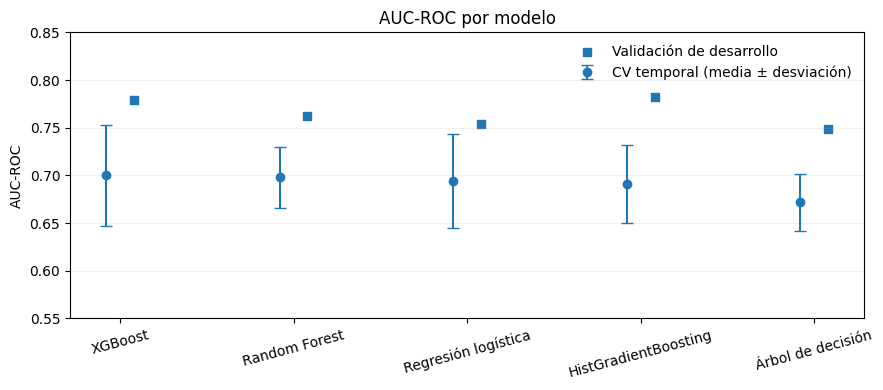

In [29]:
modelos_finales = {
    'Regresión logística': crear_pipeline_logistico(**parametros_logisticos),
    **{nombre: crear_pipeline_arbol(nombre, mejores_parametros[nombre]) for nombre in espacios}
}

filas_cv, filas_validacion = [], []
probabilidades_validacion = {}
for nombre, modelo in modelos_finales.items():
    inicio_tiempo = time.perf_counter()
    modelo.fit(X_train_maduro.loc[ambito_train], y_train_maduro.loc[ambito_train])
    segundos = time.perf_counter() - inicio_tiempo
    probabilidad = modelo.predict_proba(X_valid_fe.loc[ambito_valid])[:, 1]
    prediccion = (probabilidad >= .5).astype(int)
    probabilidades_validacion[nombre] = probabilidad

    fila_cv = mejor_logistico if nombre == 'Regresión logística' else mejores_cv.set_index('modelo').loc[nombre]
    filas_cv.append({
        'modelo': nombre, 'AUC-ROC CV': fila_cv['AUC_ROC_media'],
        'desv. AUC-ROC': fila_cv['AUC_ROC_desviacion']
    })
    filas_validacion.append({
        'modelo': nombre, 'AUC-ROC validación': roc_auc_score(y_valid_ambito, probabilidad),
        'F1 (0,5)': f1_score(y_valid_ambito, prediccion),
        'Precision (0,5)': precision_score(y_valid_ambito, prediccion, zero_division=0),
        'Recall (0,5)': recall_score(y_valid_ambito, prediccion),
        'ajuste final (s)': segundos
    })

comparacion_cv = pd.DataFrame(filas_cv).set_index('modelo').sort_values('AUC-ROC CV', ascending=False)
validacion_modelos = pd.DataFrame(filas_validacion).set_index('modelo').loc[comparacion_cv.index]
comparacion_modelos = comparacion_cv.join(validacion_modelos)
display(comparacion_cv.round(3))
display(validacion_modelos.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
posiciones = np.arange(len(comparacion_cv))
ax.errorbar(posiciones - .08, comparacion_cv['AUC-ROC CV'],
            yerr=comparacion_cv['desv. AUC-ROC'], fmt='o', capsize=4,
            label='CV temporal (media ± desviación)')
ax.scatter(posiciones + .08, validacion_modelos['AUC-ROC validación'], marker='s',
           label='Validación de desarrollo')
ax.set(title='AUC-ROC por modelo', ylabel='AUC-ROC',
       xticks=posiciones, xticklabels=comparacion_cv.index, ylim=(.55, .85))
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


F1, precisión y recall se muestran con umbral 0,5 para describir el comportamiento, pero no deciden el ganador.
El umbral se elegirá después por F1 medio en los folds temporales de entrenamiento, como criterio provisional mientras no haya costes de error. La validación externa se informa como resultado de
desarrollo y no se usa para ampliar de nuevo la búsqueda.

Nota: CV = Cross-Validation = Validación cruzada


### 9.2. Decisión provisional

**XGBoost** obtiene la mayor AUC-ROC media en CV temporal (0.700), seguido de
Random Forest (0.698). Su desviación entre folds es
0.053. En validación de desarrollo alcanza
0.779; este resultado no reabre la búsqueda.

La configuración ganadora agrupa categorías con menos de 20 reservas. La representación
categórica nativa probada anteriormente no mejoró el one-hot. El umbral y la evaluación final sobre test quedan
para el siguiente apartado.

**Modelos descartados.** SVM y KNN tendrían un coste elevado con más de 47.000 reservas y muchas columnas one-hot;
Gaussian Naive Bayes encaja mal con variables numéricas y categóricas mezcladas. LightGBM y CatBoost añadirían
dependencias y repetirían la familia de boosting ya representada por HGB y XGBoost.


### 9.3. Prueba del umbral de decisión

El umbral no cambia las probabilidades ni el AUC-ROC; cambia qué reservas se convierten en alertas. Se prueban valores entre 0,20 y 0,70 con las predicciones fuera de muestra de los tres folds temporales. Como todavía no hay costes de negocio, se elige provisionalmente el umbral con mayor F1 medio. La validación externa no interviene en esta elección.

In [30]:
predicciones_umbral = []
for fold in folds_modelado:
    modelo_fold = crear_pipeline_arbol('XGBoost', mejores_parametros['XGBoost'])
    modelo_fold.fit(fold['X_ajuste'], fold['y_ajuste'])
    predicciones_umbral.append(pd.DataFrame({
        'fold': fold['fold'],
        'real': fold['y_revision'].to_numpy(),
        'probabilidad': modelo_fold.predict_proba(fold['X_revision'])[:, 1]
    }))
predicciones_umbral = pd.concat(predicciones_umbral, ignore_index=True)

filas_umbral = []
for umbral in np.arange(.20, .71, .05):
    metricas_fold = []
    for _, datos_fold in predicciones_umbral.groupby('fold'):
        prediccion = (datos_fold['probabilidad'] >= umbral).astype(int)
        metricas_fold.append({
            'F1': f1_score(datos_fold['real'], prediccion),
            'Precision': precision_score(datos_fold['real'], prediccion, zero_division=0),
            'Recall': recall_score(datos_fold['real'], prediccion)
        })
    metricas_fold = pd.DataFrame(metricas_fold)
    alertas = predicciones_umbral['probabilidad'].ge(umbral)
    filas_umbral.append({
        'Umbral': round(umbral, 2),
        'F1 medio': metricas_fold['F1'].mean(),
        'Precision media': metricas_fold['Precision'].mean(),
        'Recall medio': metricas_fold['Recall'].mean(),
        'Alertas (%)': 100 * alertas.mean()
    })

tabla_umbrales = pd.DataFrame(filas_umbral)
umbral_elegido = float(tabla_umbrales.loc[tabla_umbrales['F1 medio'].idxmax(), 'Umbral'])
display(tabla_umbrales.set_index('Umbral').round(3))
print(f'Umbral provisional elegido por F1 medio: {umbral_elegido:.2f}')

,F1 medio,Precision media,Recall medio,Alertas (%)
Umbral,,,,
0.20,0.580,0.428,0.902,73.805
0.25,0.584,0.450,0.836,64.908
0.30,0.581,0.469,0.768,56.987
0.35,0.571,0.488,0.692,49.018
0.40,0.555,0.508,0.617,41.644
0.45,0.523,0.524,0.524,34.415
0.50,0.473,0.537,0.424,27.356
0.55,0.431,0.560,0.352,21.888
0.60,0.386,0.585,0.289,17.564


Umbral provisional elegido por F1 medio: 0.25


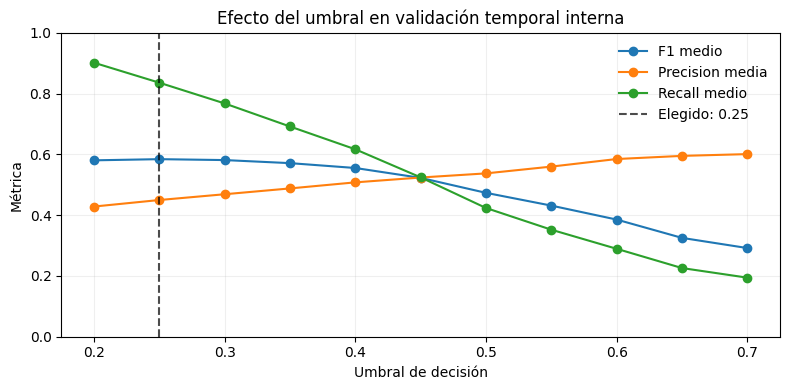

,umbral,F1,Precision,Recall,alertas,alertas (%)
criterio,,,,,,
Estándar,0.50,0.572,0.689,0.489,6848,27.146
Elegido en CV,0.25,0.639,0.507,0.862,16427,65.117


In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
for metrica in ['F1 medio', 'Precision media', 'Recall medio']:
    ax.plot(tabla_umbrales['Umbral'], tabla_umbrales[metrica], marker='o', label=metrica)
ax.axvline(umbral_elegido, color='black', linestyle='--', alpha=.7,
           label=f'Elegido: {umbral_elegido:.2f}')
ax.set(title='Efecto del umbral en validación temporal interna',
       xlabel='Umbral de decisión', ylabel='Métrica', ylim=(0, 1))
ax.grid(alpha=.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

comparacion_umbral_validacion = []
for etiqueta, umbral in [('Estándar', .5), ('Elegido en CV', umbral_elegido)]:
    prediccion = (probabilidades_validacion['XGBoost'] >= umbral).astype(int)
    comparacion_umbral_validacion.append({
        'criterio': etiqueta, 'umbral': umbral,
        'F1': f1_score(y_valid_ambito, prediccion),
        'Precision': precision_score(y_valid_ambito, prediccion, zero_division=0),
        'Recall': recall_score(y_valid_ambito, prediccion),
        'alertas': prediccion.sum(),
        'alertas (%)': 100 * prediccion.mean()
    })
comparacion_umbral_validacion = pd.DataFrame(comparacion_umbral_validacion).set_index('criterio')
display(comparacion_umbral_validacion.round(3))

**Resultado:** en los folds temporales, el umbral **0.25** maximiza el F1 medio (0.584), con precisión 0.450 y recall 0.836. En la validación externa, frente al umbral 0,50, el F1 pasa de 0.572 a 0.639, la precisión de 0.689 a 0.507 y el recall de 0.489 a 0.862. El valor es provisional: cuando existan costes de negocio, deberá elegirse comparando el coste de no detectar una cancelación con el de intervenir sobre una reserva que finalmente no se cancela.

## 10. Selección del modelo y del umbral

### 10.1. Decisión del modelo

Se selecciona **XGBoost** con el criterio fijado de AUC-ROC media en validación temporal. Su ventaja frente a la regresión logística es moderada en CV (0,700 frente a 0,694), pero también mejora en la validación externa (0,779 frente a 0,754), con una variabilidad temporal parecida (0,053 frente a 0,049) y un tiempo de ajuste asumible. HistGradientBoosting logra 0,782 en el único periodo externo, pero queda por debajo en el criterio de selección temporal; Random Forest casi iguala el CV, aunque rinde peor fuera.

La mejora sobre el baseline no es amplia, por lo que la regresión logística sigue siendo una referencia defendible y más interpretable. Se mantiene XGBoost porque la mejora de ordenación aparece tanto en CV como en el periodo externo, y la decisión respeta el criterio definido antes de observar el test.

In [32]:
MODELO_FINAL = 'XGBoost'
UMBRAL_FINAL = .25
PARAMETROS_FINALES = mejores_parametros[MODELO_FINAL].copy()
VARIABLES_NUMERICAS_FINALES = tuple(variables_numericas)
VARIABLES_CATEGORICAS_FINALES = tuple(variables_categoricas)
VARIABLES_BINARIAS_FINALES = tuple(variables_binarias)
modelo_final_fijado = crear_pipeline_arbol(MODELO_FINAL, PARAMETROS_FINALES)

configuracion_final = pd.Series({
    'modelo': MODELO_FINAL, 'umbral': UMBRAL_FINAL,
    'métrica de selección': 'AUC-ROC temporal',
    'criterio del umbral': 'máximo F1 medio temporal',
    'variables antes de codificar': (len(VARIABLES_NUMERICAS_FINALES)
        + len(VARIABLES_CATEGORICAS_FINALES) + len(VARIABLES_BINARIAS_FINALES)),
    'preprocesamiento': 'imputación + one-hot; sin escalado para XGBoost'
}, name='decisión final')
display(configuracion_final.to_frame())
display(pd.Series(PARAMETROS_FINALES, name='valor').to_frame())

,decisión final
modelo,XGBoost
umbral,0.25
métrica de selección,AUC-ROC temporal
criterio del umbral,máximo F1 medio temporal
variables antes de codificar,24
preprocesamiento,imputación + one-hot; sin escalado para XGBoost


,valor
colsample_bytree,0.911562
learning_rate,0.069298
max_depth,3.000000
min_child_weight,9.000000
min_frequency,20.000000
n_estimators,190.000000
reg_alpha,0.012471
reg_lambda,0.035120
subsample,0.655473


### 10.2. Umbral seleccionado

Se fija **0,25**, que maximiza el F1 medio de las predicciones fuera de muestra de los folds temporales. Es un criterio provisional porque no conocemos costes ni capacidad de intervención. La validación externa ya se ha consultado durante el desarrollo; por tanto, sus métricas ayudan a seleccionar y describir la solución, pero no son una evaluación final independiente.

,F1,Precision,Recall,verdaderos negativos,falsos positivos,falsos negativos,verdaderos positivos,reservas señaladas (%)
criterio,,,,,,,,
"Umbral 0,50",0.572,0.689,0.489,13441,2129,4938,4719,27.146
"Umbral 0,25",0.639,0.507,0.862,7472,8098,1328,8329,65.117


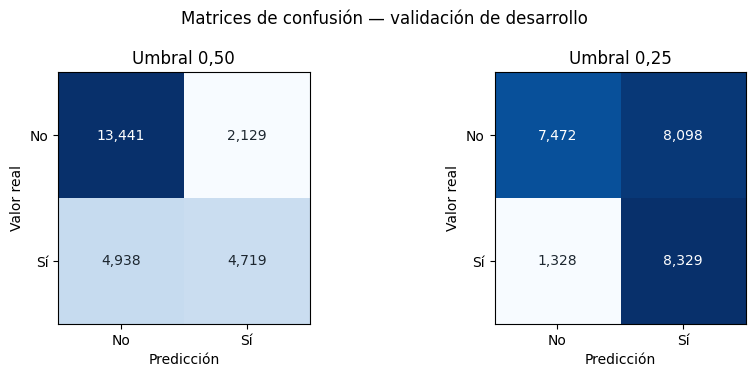

In [33]:
probabilidad_final_valid = probabilidades_validacion[MODELO_FINAL]
comparacion_final, matrices_finales = [], {}
for etiqueta, umbral in [('Umbral 0,50', .5), ('Umbral 0,25', UMBRAL_FINAL)]:
    prediccion = (probabilidad_final_valid >= umbral).astype(int)
    matriz = confusion_matrix(y_valid_ambito, prediccion)
    matrices_finales[etiqueta] = matriz
    tn, fp, fn, tp = matriz.ravel()
    comparacion_final.append({
        'criterio': etiqueta, 'F1': f1_score(y_valid_ambito, prediccion),
        'Precision': precision_score(y_valid_ambito, prediccion, zero_division=0),
        'Recall': recall_score(y_valid_ambito, prediccion),
        'verdaderos negativos': tn, 'falsos positivos': fp,
        'falsos negativos': fn, 'verdaderos positivos': tp,
        'reservas señaladas (%)': 100 * prediccion.mean()
    })
comparacion_final = pd.DataFrame(comparacion_final).set_index('criterio')
display(comparacion_final.round(3))

fig, ejes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, (etiqueta, matriz) in zip(ejes, matrices_finales.items()):
    ax.imshow(matriz, cmap='Blues')
    for fila in range(2):
        for columna in range(2):
            ax.text(columna, fila, f'{matriz[fila, columna]:,}', ha='center', va='center',
                    color='white' if matriz[fila, columna] > matriz.max() / 2 else '#1d2730')
    ax.set(title=etiqueta, xlabel='Predicción', ylabel='Valor real',
           xticks=[0, 1], yticks=[0, 1], xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
fig.suptitle('Matrices de confusión — validación de desarrollo')
fig.tight_layout()
plt.show()

Con 0,25, el F1 sube de **0.572** a **0.639** y el recall de 0.489 a 0.862; a cambio, la precisión baja de 0.689 a 0.507. Las reservas señaladas pasan del 27.1% al **65.1%**. Se reducen los falsos negativos de 4,938 a 1,328, pero los falsos positivos aumentan de 2,129 a 8,098. Sin costes ni capacidad operativa, F1 es solo un compromiso provisional entre Precision y Recall.

,Brier
XGBoost,0.180
Probabilidad constante,0.236


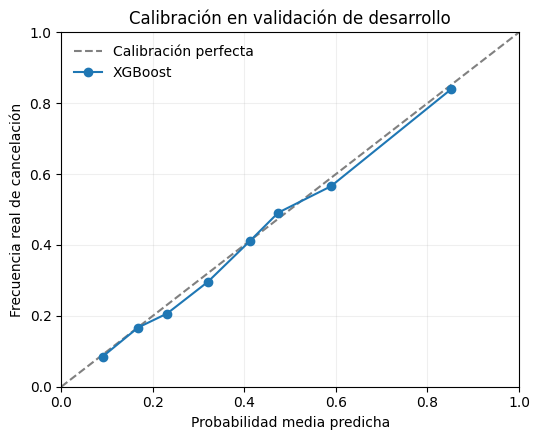

In [34]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier_modelo = brier_score_loss(y_valid_ambito, probabilidad_final_valid)
brier_referencia = brier_score_loss(
    y_valid_ambito, np.repeat(y_valid_ambito.mean(), len(y_valid_ambito))
)
fraccion_real, probabilidad_media = calibration_curve(
    y_valid_ambito, probabilidad_final_valid, n_bins=8, strategy='quantile'
)
display(pd.DataFrame({'Brier': [brier_modelo, brier_referencia]},
                     index=['XGBoost', 'Probabilidad constante']).round(3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot([0, 1], [0, 1], '--', color='grey', label='Calibración perfecta')
ax.plot(probabilidad_media, fraccion_real, marker='o', label='XGBoost')
ax.set(title='Calibración en validación de desarrollo',
       xlabel='Probabilidad media predicha', ylabel='Frecuencia real de cancelación',
       xlim=(0, 1), ylim=(0, 1))
ax.grid(alpha=.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### 10.3. Capacidad de ordenación, calibración y cierre

El AUC-ROC evalúa la **ordenación del riesgo**. El Brier de XGBoost es **0.180**, frente a 0.236 de asignar a todas las reservas la tasa media. Sin embargo, la curva se separa de la diagonal hasta 2.5 puntos porcentuales en los grupos mostrados. Por ello, las probabilidades sirven para ordenar y aplicar el umbral, pero no deben comunicarse como probabilidades perfectamente calibradas.

**Queda fijado:** XGBoost, sus hiperparámetros, las listas de variables, el preprocesamiento, la regla de ADR y el umbral 0,25.

**Evaluación en test:** se utilizará el mismo pipeline ya ajustado solo con entrenamiento. No se incorporará validación al ajuste, porque reentrenar podría cambiar las probabilidades para las que se eligió el umbral 0,25. Una futura calibración o un nuevo entrenamiento requerirían fijar de nuevo el umbral con datos anteriores a un nuevo test.

## 11. Evaluación final en test

### 11.1. Configuración cerrada antes de evaluar

Se evalúa el **mismo XGBoost ajustado solo con entrenamiento** en el apartado 9. No se añade validación al ajuste, porque reentrenar podría cambiar la escala de las probabilidades para la que se seleccionó el umbral 0,25. La clase positiva es `is_canceled = 1`. El test no interviene en la imputación, la codificación, el límite de ADR, los hiperparámetros ni el umbral.

In [35]:
modelo_evaluado = modelos_finales[MODELO_FINAL]  # ya ajustado; aquí no se llama a fit
idx_entrenamiento_modelo = X_train_maduro.index[ambito_train]
configuracion_test = pd.Series({
    'modelo': MODELO_FINAL,
    'reservas usadas para ajustar': len(idx_entrenamiento_modelo),
    'periodo de reserva del ajuste': (
        f"{fecha_reserva_est.loc[idx_entrenamiento_modelo].min().date()} a "
        f"{fecha_reserva_est.loc[idx_entrenamiento_modelo].max().date()}"
    ),
    'validación añadida al ajuste': 'No',
    'ámbito ADR aprendido': f'0 < ADR ≤ {limite_adr:.2f} €',
    'preprocesamiento': 'mediana + categoría -1 + one-hot; sin escalado',
    'umbral': UMBRAL_FINAL
}, name='configuración')
variables_test = pd.Series({
    'numéricas': ', '.join(VARIABLES_NUMERICAS_FINALES),
    'categóricas': ', '.join(VARIABLES_CATEGORICAS_FINALES),
    'binarias': ', '.join(VARIABLES_BINARIAS_FINALES)
}, name='variables fijadas')
display(configuracion_test.to_frame())
display(pd.Series(PARAMETROS_FINALES, name='hiperparámetro').to_frame())
display(variables_test.to_frame())

,configuración
modelo,XGBoost
reservas usadas para ajustar,47006
periodo de reserva del ajuste,2014-03-18 a 2016-06-29
validación añadida al ajuste,No
ámbito ADR aprendido,0 < ADR ≤ 205.59 €
preprocesamiento,mediana + categoría -1 + one-hot; sin escalado
umbral,0.25


,hiperparámetro
colsample_bytree,0.911562
learning_rate,0.069298
max_depth,3.000000
min_child_weight,9.000000
min_frequency,20.000000
n_estimators,190.000000
reg_alpha,0.012471
reg_lambda,0.035120
subsample,0.655473


,variables fijadas
numéricas,"lead_time, arrival_date_year, arrival_date_wee..."
categóricas,"hotel, arrival_date_month, meal, market_segmen..."
binarias,"has_children, arrival_weekend"


In [ ]:
filas_validas_test = filas_modelo.loc[X_test.index]
X_test_fe = crear_variables(X_test.loc[filas_validas_test])
y_test_fe = y_test.loc[X_test_fe.index]
ambito_test = X_test_fe['adr'].gt(0) & X_test_fe['adr'].le(limite_adr)
X_test_evaluacion = X_test_fe.loc[ambito_test]
y_test_evaluacion = y_test_fe.loc[ambito_test]
probabilidad_test = modelo_evaluado.predict_proba(X_test_evaluacion)[:, 1]
prediccion_test = (probabilidad_test >= UMBRAL_FINAL).astype(int)

resumen_test = pd.Series({
    'periodo de reserva': (
        f"{fecha_reserva_est.loc[X_test.index].min().date()} a "
        f"{fecha_reserva_est.loc[X_test.index].max().date()}"
    ),
    'reservas del periodo': len(X_test),
    'reservas evaluadas': len(X_test_evaluacion),
    'reservas excluidas por reglas fijadas': len(X_test) - len(X_test_evaluacion),
    'tasa de cancelación total (%)': 100 * y_test.mean(),
    'tasa de cancelación evaluada (%)': 100 * y_test_evaluacion.mean(),
    'reservas señaladas (%)': 100 * prediccion_test.mean()
}, name='test')
display(resumen_test.to_frame())

,test
periodo de reserva,2017-01-01 a 2017-08-31
reservas del periodo,26565
reservas evaluadas,23831
reservas excluidas por reglas fijadas,2734
tasa de cancelación total (%),31.628082
tasa de cancelación evaluada (%),31.089757
reservas señaladas (%),58.054635


,reservas,cancelación (%),AUC-ROC,F1,Precision,Recall,señaladas (%)
periodo,,,,,,,
Validación,25227,38.28,0.779,0.639,0.507,0.862,65.117
Test,23831,31.09,0.764,0.586,0.450,0.840,58.055


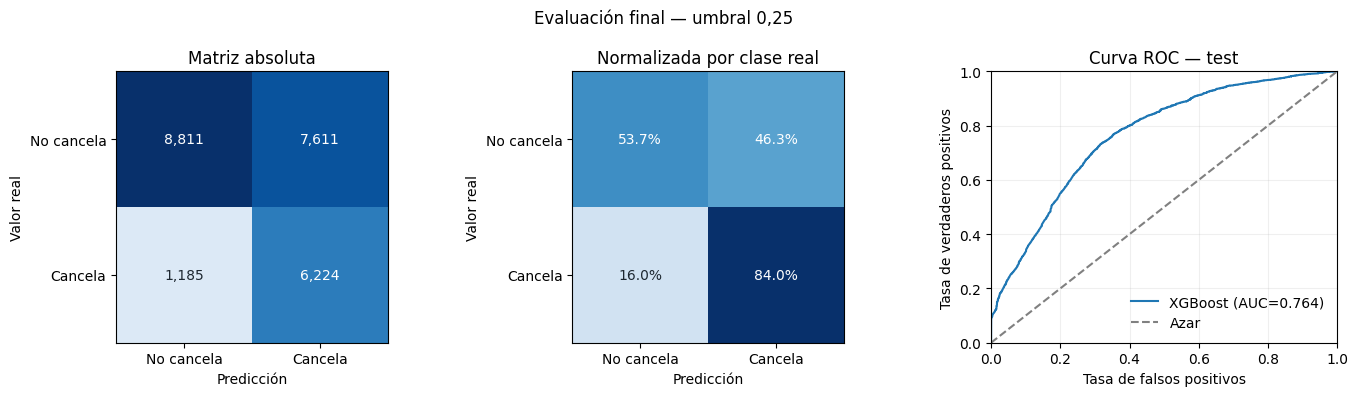

In [37]:
metricas_periodos = []
for periodo, reales, probabilidades in [
    ('Validación', y_valid_ambito, probabilidades_validacion[MODELO_FINAL]),
    ('Test', y_test_evaluacion, probabilidad_test)
]:
    predicciones = (probabilidades >= UMBRAL_FINAL).astype(int)
    metricas_periodos.append({
        'periodo': periodo, 'reservas': len(reales),
        'cancelación (%)': 100 * reales.mean(),
        'AUC-ROC': roc_auc_score(reales, probabilidades),
        'F1': f1_score(reales, predicciones),
        'Precision': precision_score(reales, predicciones, zero_division=0),
        'Recall': recall_score(reales, predicciones),
        'señaladas (%)': 100 * predicciones.mean()
    })
comparacion_final_test = pd.DataFrame(metricas_periodos).set_index('periodo')
display(comparacion_final_test.round(3))

matriz_test = confusion_matrix(y_test_evaluacion, prediccion_test)
matriz_test_normalizada = confusion_matrix(
    y_test_evaluacion, prediccion_test, normalize='true'
)
fpr_test, tpr_test, _ = roc_curve(y_test_evaluacion, probabilidad_test)

fig, ejes = plt.subplots(1, 3, figsize=(14, 4))
for ax, matriz, titulo, formato in [
    (ejes[0], matriz_test, 'Matriz absoluta', ',d'),
    (ejes[1], matriz_test_normalizada, 'Normalizada por clase real', '.1%')
]:
    ax.imshow(matriz, cmap='Blues', vmin=0)
    for fila in range(2):
        for columna in range(2):
            ax.text(columna, fila, format(matriz[fila, columna], formato),
                    ha='center', va='center',
                    color='white' if matriz[fila, columna] > matriz.max() / 2 else '#1d2730')
    ax.set(title=titulo, xlabel='Predicción', ylabel='Valor real',
           xticks=[0, 1], yticks=[0, 1],
           xticklabels=['No cancela', 'Cancela'], yticklabels=['No cancela', 'Cancela'])
ejes[2].plot(fpr_test, tpr_test, label=f"XGBoost (AUC={roc_auc_score(y_test_evaluacion, probabilidad_test):.3f})")
ejes[2].plot([0, 1], [0, 1], '--', color='grey', label='Azar')
ejes[2].set(title='Curva ROC — test', xlabel='Tasa de falsos positivos',
            ylabel='Tasa de verdaderos positivos', xlim=(0, 1), ylim=(0, 1))
ejes[2].grid(alpha=.2)
ejes[2].legend(frameon=False)
fig.suptitle('Evaluación final — umbral 0,25')
fig.tight_layout()
plt.show()

### 11.2. Resultado e interpretación

El test contiene 26,565 reservas del 2017-01-01 al 2017-08-31; 23,831 entran en el ámbito fijado y su tasa de cancelación es 31.1%. Con el umbral 0,25 se señalan 58.1% de las reservas evaluadas. El modelo detecta **6,224 cancelaciones**, omite **1,185** y señalaría innecesariamente **7,611 reservas no canceladas**. Quedan fuera 2,734 reservas (10.3%) por las reglas de calidad y ADR fijadas; las métricas finales describen únicamente el ámbito evaluado.

Frente a validación, el AUC-ROC pasa de 0.779 a **0.764**, el F1 de 0.639 a **0.586**, la precisión de 0.507 a **0.450** y el recall de 0.862 a **0.840**. La tasa de cancelación cambia de 38.3% a 31.1%. Las diferencias podrían relacionarse con cambios temporales en la mezcla de reservas, la estacionalidad o la tasa base, pero este test no permite atribuirlas a una causa concreta.

### 11.3. Cierre de la evaluación

La configuración queda cerrada y **no se modifica después de observar el test**. Cualquier calibración, nuevo umbral, variable o ajuste de hiperparámetros deberá considerarse trabajo futuro y evaluarse con una partición nueva, no con este mismo test. No se añade un análisis por hotel o mes para evitar convertir el test en una nueva fuente de decisiones durante esta evaluación final.

## 12. Interpretabilidad con SHAP

SHAP reparte la diferencia entre la salida de una reserva y un valor de referencia entre las variables. Se usa el algoritmo **TreeSHAP nativo de XGBoost**, que calcula contribuciones exactas para sus árboles. La explicación utiliza la salida bruta de XGBoost para la clase positiva (`is_canceled = 1`): las contribuciones están en **log-odds**. Su suma más el valor de referencia reconstruye el margen del modelo; al aplicar la función logística se obtiene `predict_proba[:, 1]`. No se necesita una muestra externa de fondo: el valor base procede del ensemble ajustado con entrenamiento.

La explicación global utiliza una muestra aleatoria reproducible de 500 reservas del ámbito de test (`random_state=42`). El muestreo no depende del resultado real ni de si el modelo acertó.

In [38]:
import sys
from pathlib import Path
ruta_shap = str(Path('.shap_lib').resolve())
if ruta_shap not in sys.path:
    sys.path.append(ruta_shap)
import shap
from scipy.special import expit
from xgboost import DMatrix

preprocesador_final = modelo_evaluado.named_steps['preprocesamiento']
xgboost_final = modelo_evaluado.named_steps['modelo']
muestra_shap = X_test_evaluacion.sample(n=500, random_state=SEMILLA)
muestra_modelo_shap = preprocesador_final.transform(muestra_shap)
muestra_transformada = (
    muestra_modelo_shap.toarray()
    if hasattr(muestra_modelo_shap, 'toarray') else muestra_modelo_shap
)
nombres_transformados = [
    nombre.split('__', 1)[-1]
    for nombre in preprocesador_final.get_feature_names_out()
]

contribuciones_shap = xgboost_final.get_booster().predict(
    DMatrix(muestra_modelo_shap), pred_contribs=True
)
valores_shap = contribuciones_shap[:, :-1]
valor_referencia = float(contribuciones_shap[0, -1])
margen_reconstruido = contribuciones_shap.sum(axis=1)
probabilidad_reconstruida = expit(margen_reconstruido)
probabilidad_modelo = modelo_evaluado.predict_proba(muestra_shap)[:, 1]
error_reconstruccion = np.abs(probabilidad_reconstruida - probabilidad_modelo)

comprobacion_shap = pd.Series({
    'conjunto explicado': 'test', 'reservas explicadas': len(muestra_shap),
    'referencia': 'valor base del ensemble entrenado',
    'valor de referencia (log-odds)': valor_referencia,
    'probabilidad de referencia': expit(valor_referencia),
    'salida explicada': 'log-odds de is_canceled = 1',
    'error máximo de reconstrucción': f'{error_reconstruccion.max():.2e}'
}, name='SHAP')
display(comprobacion_shap.to_frame())

c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,SHAP
conjunto explicado,test
reservas explicadas,500
referencia,valor base del ensemble entrenado
valor de referencia (log-odds),-0.564635
probabilidad de referencia,0.362476
salida explicada,log-odds de is_canceled = 1
error máximo de reconstrucción,2.38e-07


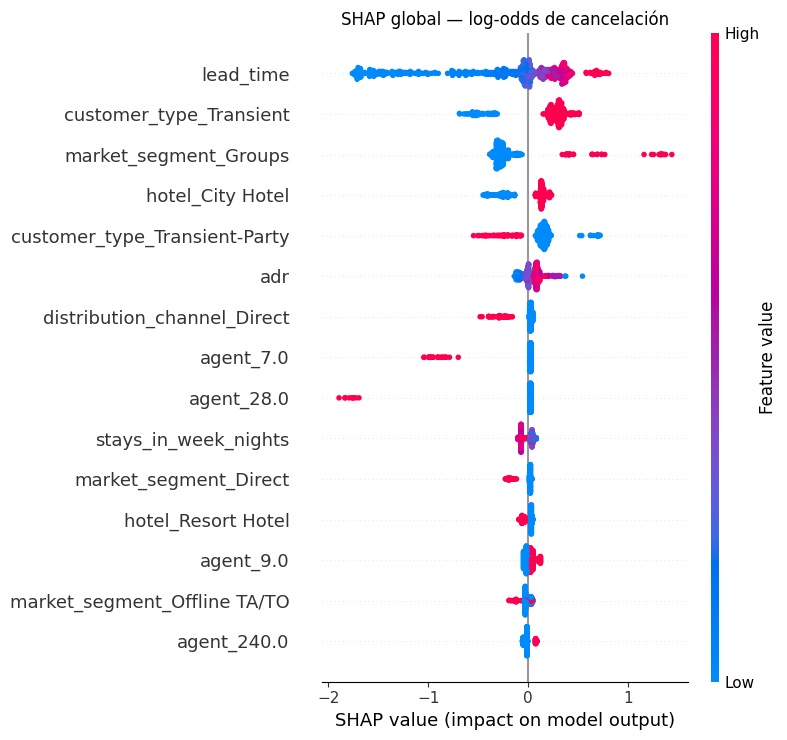

,contribución absoluta media
lead_time,0.5207
customer_type,0.4865
market_segment,0.3371
hotel,0.2151
agent,0.1728
adr,0.0737
distribution_channel,0.0654
stays_in_week_nights,0.0472
arrival_date_month,0.0329
reserved_room_type,0.0272


In [39]:
shap.summary_plot(
    valores_shap, muestra_transformada, feature_names=nombres_transformados,
    max_display=15, show=False
)
plt.title('SHAP global — log-odds de cancelación')
plt.tight_layout()
plt.show()

origen_variables = []
for nombre_completo, nombre_limpio in zip(
    preprocesador_final.get_feature_names_out(), nombres_transformados
):
    bloque = nombre_completo.split('__', 1)[0]
    if bloque != 'cat':
        origen_variables.append(nombre_limpio)
    else:
        coincidencias = [
            variable for variable in VARIABLES_CATEGORICAS_FINALES
            if nombre_limpio.startswith(f'{variable}_')
        ]
        origen_variables.append(max(coincidencias, key=len))

shap_agrupado = pd.DataFrame({
    variable: valores_shap[:, np.array(origen_variables) == variable].sum(axis=1)
    for variable in dict.fromkeys(origen_variables)
})
importancia_agrupada = shap_agrupado.abs().mean().sort_values(ascending=False).rename(
    'contribución absoluta media'
).to_frame()
display(importancia_agrupada.head(12).round(4))

El *summary plot* conserva cada columna *one-hot* por separado para mostrar qué categoría concreta aumenta o reduce la puntuación. La tabla complementaria vuelve al nivel de variable original: para cada reserva se suman las contribuciones de todas las categorías de una misma variable y después se calcula su magnitud media. Con este criterio destacan **lead_time**, **customer_type**, **market_segment**, **hotel** y **agent**. Los puntos a la derecha elevan la probabilidad estimada y los situados a la izquierda la reducen.

In [40]:
percentiles = np.quantile(probabilidad_test, [.10, .90])
posiciones_casos = [
    int(np.abs(probabilidad_test - percentiles[1]).argmin()),
    int(np.abs(probabilidad_test - percentiles[0]).argmin())
]
etiquetas_casos = ['Riesgo alto (percentil 90)', 'Riesgo bajo (percentil 10)']
indices_casos = X_test_evaluacion.index[posiciones_casos]
X_casos = X_test_evaluacion.loc[indices_casos]
casos_modelo_shap = preprocesador_final.transform(X_casos)
casos_transformados = (
    casos_modelo_shap.toarray()
    if hasattr(casos_modelo_shap, 'toarray') else casos_modelo_shap
)
contribuciones_casos = xgboost_final.get_booster().predict(
    DMatrix(casos_modelo_shap), pred_contribs=True
)
shap_casos = contribuciones_casos[:, :-1]

columnas_casos = [
    'hotel', 'lead_time', 'adr', 'market_segment', 'distribution_channel',
    'customer_type', 'total_guests', 'total_nights', 'has_children', 'booking_month'
]
tabla_casos = X_casos[columnas_casos].copy()
tabla_casos.insert(0, 'caso', etiquetas_casos)
tabla_casos['probabilidad'] = probabilidad_test[posiciones_casos]
tabla_casos['umbral'] = UMBRAL_FINAL
tabla_casos['predicción'] = (tabla_casos['probabilidad'] >= UMBRAL_FINAL).map(
    {True: 'Cancela', False: 'No cancela'}
)
tabla_casos['resultado real'] = y_test_evaluacion.loc[indices_casos].map(
    {1: 'Canceló', 0: 'No canceló'}
)
display(tabla_casos.set_index('caso').T)

caso,Riesgo alto (percentil 90),Riesgo bajo (percentil 10)
hotel,City Hotel,Resort Hotel
lead_time,123,14
adr,125.0,101.33
market_segment,Online TA,Online TA
distribution_channel,TA/TO,TA/TO
customer_type,Transient,Transient
total_guests,2.0,2.0
total_nights,2,3
has_children,0,0
booking_month,4,5


In [ ]:
for posicion, etiqueta in enumerate(etiquetas_casos):
    plt.figure(figsize=(8, 6))
    explicacion_caso = shap.Explanation(
        values=shap_casos[posicion], base_values=valor_referencia,
        data=casos_transformados[posicion], feature_names=nombres_transformados
    )
    shap.plots.waterfall(explicacion_caso, max_display=12, show=False)
    plt.title(f'{etiqueta} — contribuciones a log-odds')
    plt.tight_layout()
    plt.show()

### 12.3. Lectura de los casos y conclusión de negocio

La reserva de riesgo alto recibe una probabilidad de **0,564**, por encima del umbral 0,25. Su perfil *Transient*, los 123 días de antelación, el City Hotel y un ADR de 125 € empujan la estimación al alza; no pertenecer al segmento Groups la reduce. La reserva de riesgo bajo recibe **0,084**: el agente 241, una antelación de 14 días y el Resort Hotel reducen especialmente su puntuación, aunque el tipo *Transient* aporta riesgo. Ambas coincidieron con el resultado real, pero fueron elegidas por los percentiles 90 y 10 de la puntuación, sin utilizar ese resultado.

Globalmente, el modelo asigna más riesgo a antelaciones largas, clientes *Transient*, reservas del segmento Groups, City Hotel y ADR más altos. *Transient-Party*, el canal Direct y Resort Hotel suelen empujar en sentido contrario. Los agentes concretos pueden actuar en ambas direcciones y su código no debe interpretarse como una escala numérica. Estas contribuciones describen el comportamiento aprendido por XGBoost y permiten priorizar revisiones; no demuestran que intervenir sobre una característica provoque o evite una cancelación.

## 13. Propuesta de uso y limitaciones

### 13.1. Uso por Revenue Management

El riesgo se calcularía **al crear la reserva**, con una instantánea de los datos disponibles entonces. Revenue Management consultaría una lista de reservas ordenada por puntuación. El **0,25** elegido en entrenamiento marcaría qué reservas revisar; dentro de ellas, las de mayor puntuación podrían recibir prioridad si hubiera capacidad. No se fija un segundo corte ni un volumen operativo sin conocer esa capacidad.

Una reserva no señalada seguiría el proceso habitual. Para las señaladas se podría probar un recordatorio automático de las condiciones de reserva; entre las de mayor riesgo, una confirmación personalizada. **La predicción indica a quién estudiar, no qué acción funciona.** La utilidad de cada medida debe medirse en un piloto antes de recomendarla.

En test, el umbral 0,25 detectó **6.224** cancelaciones, omitió **1.185** y señaló **7.611** reservas que no se cancelaron: el **58,1 %** de las reservas evaluadas recibiría una alerta. Reducir las omisiones implica más intervenciones innecesarias. No conocemos su coste, el de una cancelación ni la capacidad de gestión; por ello no estimamos ahorro o rentabilidad.

### 13.2. Límites observados

- **Momento de predicción:** varios campos, incluidos `adr`, `agent`, `customer_type` y el canal, solo son plausiblemente iniciales; el fichero no confirma su valor exacto al reservar. La fecha de reserva se reconstruyó como llegada menos `lead_time`. La disponibilidad de etiquetas se aproximó mediante la salida prevista, no mediante un historial real de consolidación.
- **Calidad y cobertura:** faltan valores y existen duplicados; se excluyeron reservas sin huéspedes o noches válidas, con `children` ausente o con ADR fuera del ámbito aprendido. En test quedaron fuera **2.734 de 26.565 reservas (10,3 %)**, a las que estas métricas no se aplican.
- **Representatividad:** los datos corresponden a dos hoteles y a un periodo histórico limitado, con cobertura parcial en los extremos. La tasa de cancelación del ámbito evaluado bajó del **38,3 %** en validación al **31,1 %** en test. No se ha demostrado el mismo rendimiento en otros hoteles ni en años posteriores.

### 13.3. Piloto y próximos pasos

Primero se verificarían las **instantáneas al reservar** y el registro de cuándo madura cada etiqueta. Después, un piloto prospectivo registraría puntuación, acción, coste y resultado. Entre reservas elegibles para una intervención concreta, una asignación aleatoria a intervención o proceso habitual permitiría estimar su efecto sobre cancelaciones y, si se recogen los datos, sobre ingreso neto. El rendimiento predictivo por sí solo no mide ese efecto.

Durante el piloto convendría vigilar: nulos, valores imposibles y reservas fuera del ámbito; cambios en las distribuciones de variables y puntuaciones; proporción de alertas por hotel y periodo; y, **cuando las etiquetas estén maduras**, AUC-ROC, Precision, Recall, tasa de cancelación y calibración. Las tres prioridades son **(1)** comprobar la disponibilidad real de los predictores, **(2)** medir causalmente una intervención sencilla y su carga operativa, y **(3)** validar el sistema en un periodo nuevo y estudiar las reservas excluidas antes de extenderlo a otros hoteles.

## 14.Conclusiones de negocio

El objetivo fue **priorizar reservas con riesgo de cancelación al reservar**. En entrenamiento, City Hotel tuvo una tasa de cancelación de **44,6 %** frente a **28,6 %** en Resort Hotel; la antelación y el canal también se asociaron con diferencias de riesgo. El ADR medio fue parecido entre reservas no canceladas y canceladas (**92,75 €** y **93,90 €**, respectivamente), por lo que ese promedio aislado aporta poco para decidir.

Se eligió **XGBoost**, con las variables y el preprocesamiento fijados en los apartados 7–10, entrenado con **47.006** reservas maduras de entrenamiento y umbral **0,25**. En las **23.831** reservas elegibles de test de **enero a agosto de 2017** (tasa de cancelación **31,1 %**), obtuvo **AUC-ROC 0,764, F1 0,586, Precision 0,450 y Recall 0,840**. Detectó **6.224** cancelaciones y omitió **1.185**; **7.611** reservas que no se cancelaron recibirían una alerta. El **58,1 %** del test elegible quedó señalado. El rendimiento fue inferior al de validación (AUC-ROC **0,779**, F1 **0,639**), en un periodo con distinta tasa de cancelación; esto no demuestra por sí solo la causa de la diferencia.

SHAP atribuye globalmente mayor influencia a `lead_time`, `customer_type`, `market_segment`, `hotel` y `agent`. Entre los dos casos elegidos por percentiles de puntuación, la reserva de riesgo alto (**0,564**) combinó cliente *Transient*, **123 días** de antelación y City Hotel; la de riesgo bajo (**0,084**) tenía **14 días** de antelación y Resort Hotel. Son explicaciones de las puntuaciones del modelo, no de las causas de la cancelación.

Revenue Management podría revisar primero las reservas señaladas y **evaluar** un recordatorio o una confirmación en un piloto con grupo de comparación. La predicción no determina qué acción previene cancelaciones. Antes de utilizarla habría que comprobar los valores disponibles al reservar, medir el efecto y la carga operativa de la intervención y evaluar un periodo nuevo. Los datos proceden de **dos hoteles históricos**; además, **2.734 de 26.565** reservas del periodo de test (**10,3 %**) quedaron fuera del ámbito evaluado. No se puede extrapolar el rendimiento a esas reservas, otros hoteles o años posteriores sin validación adicional.